Period bins: [(0.6004693000326413, 1.0658330075579383), (1.0658330075579383, 1.8916659324521337), (1.8916659324521337, 3.356998659517159), (3.356998659517159, 5.957706270033796), (5.957706270033796, 10.573579431772384), (10.573579431772384, 18.76566012694464), (18.76566012694464, 33.30728148618558)]
Radius bins: [(1.7025839175433728, 1.9885069776090805), (1.9885069776090805, 2.3224965016120045), (2.3224965016120045, 2.7128066646924913), (2.7128066646924913, 3.168927263286426), (3.168927263286426, 3.701351104664349), (3.701351104664349, 4.322841255671914)]
Removing 0 rows with missing stellar mass
Dataframe size after removal: 2728 rows
False positive cells removed: 37
Processing 56 unique TICs in temperature range 3000-3500 K


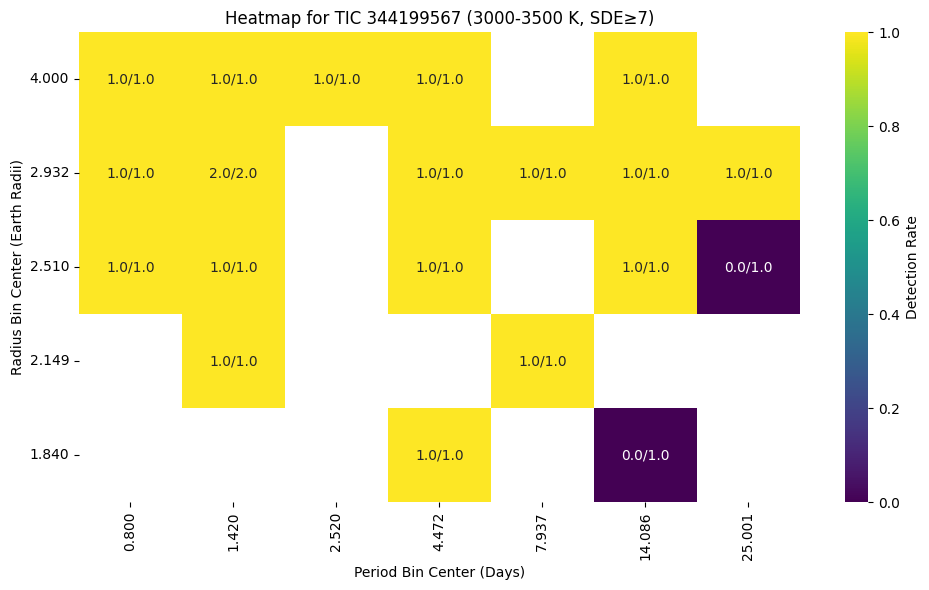

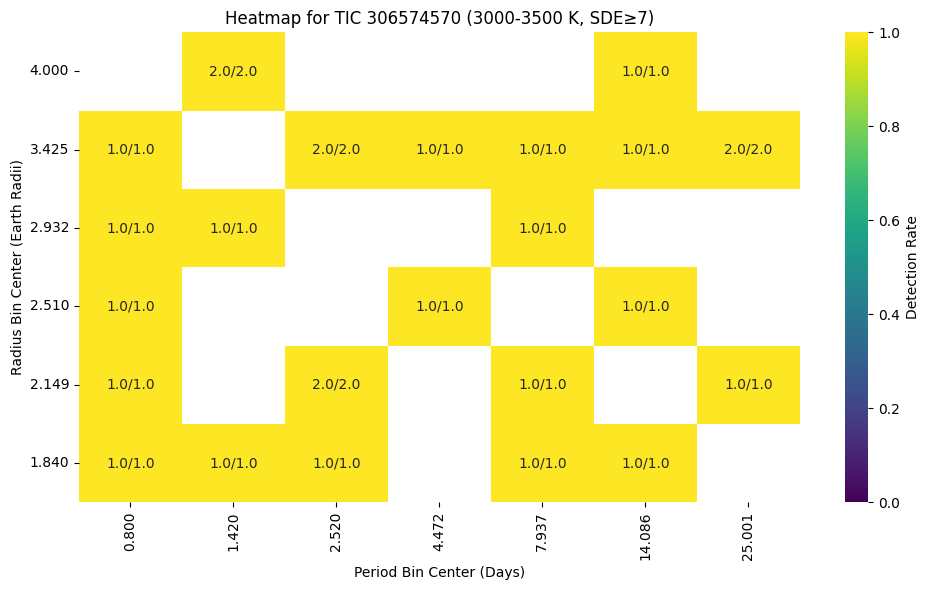

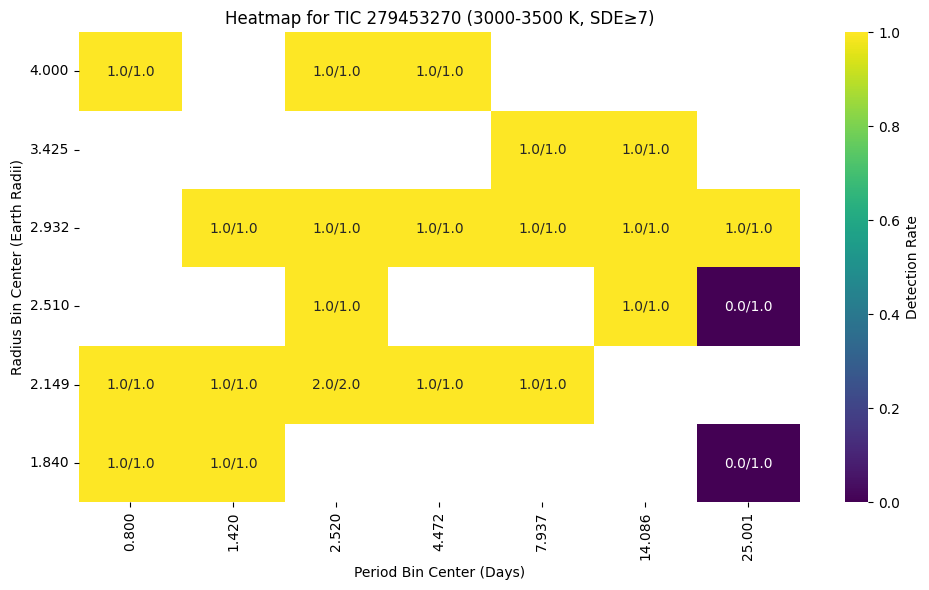

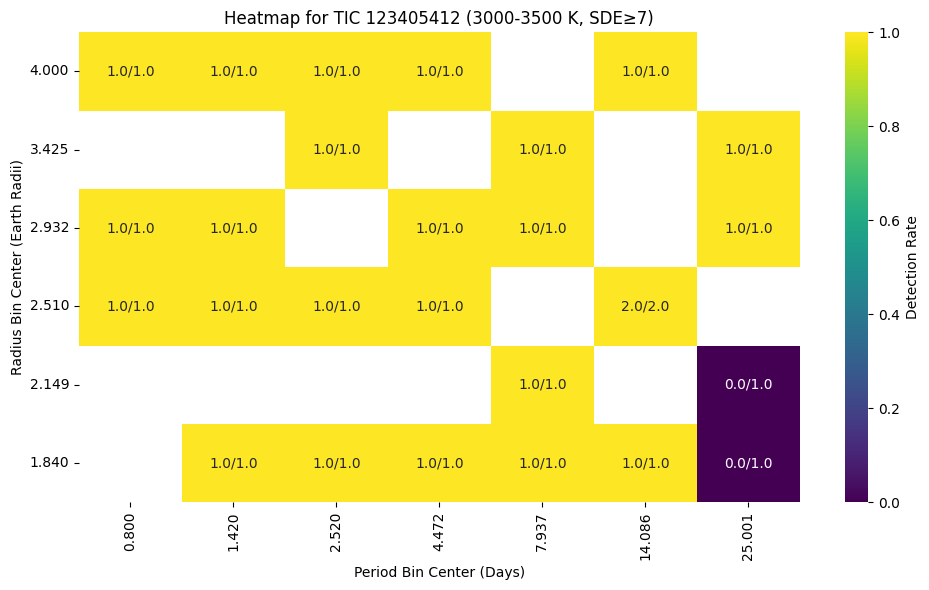

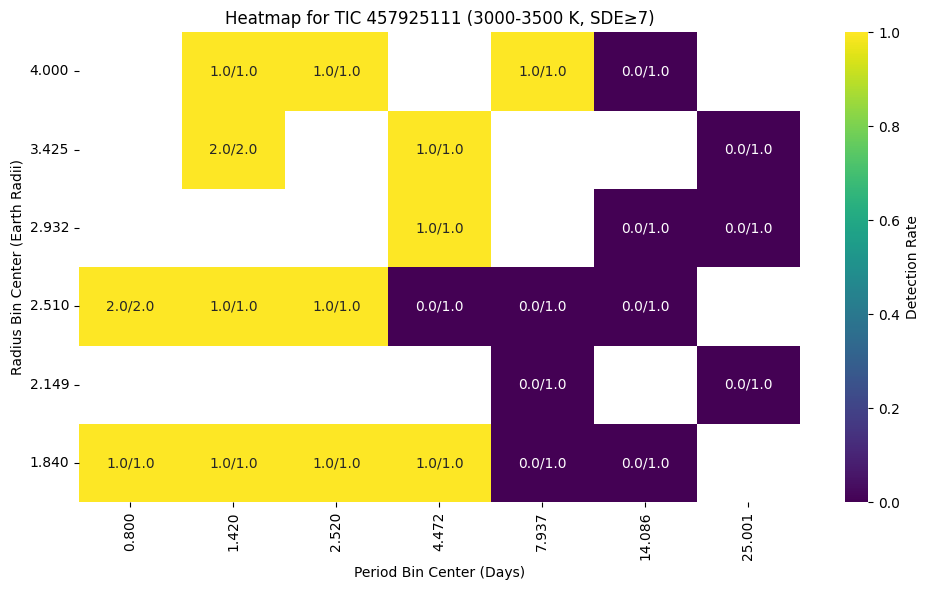

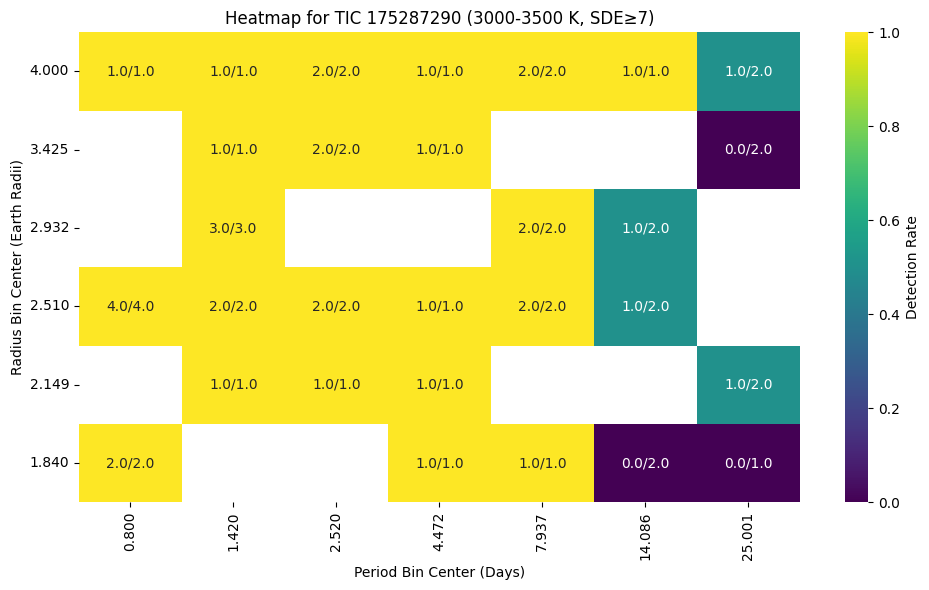

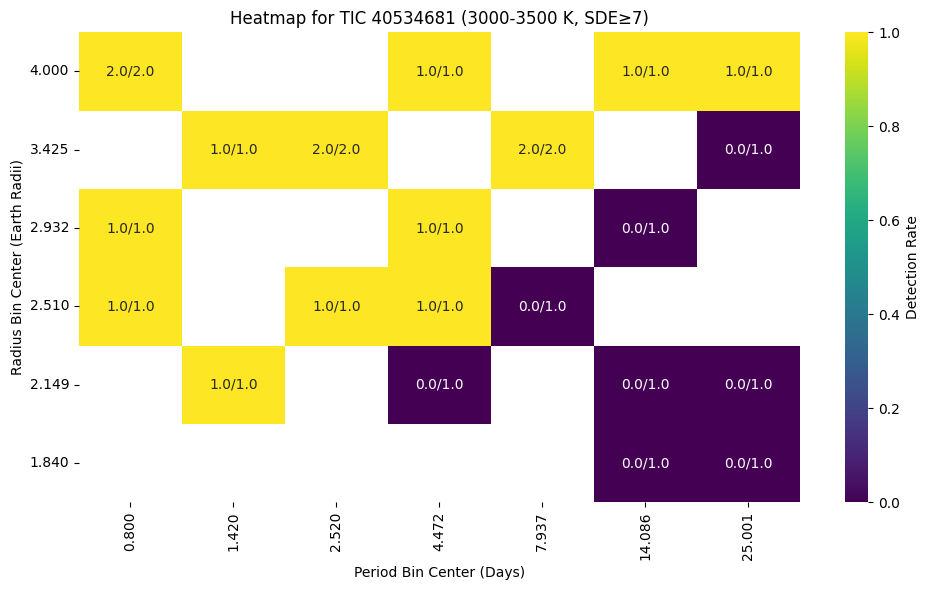

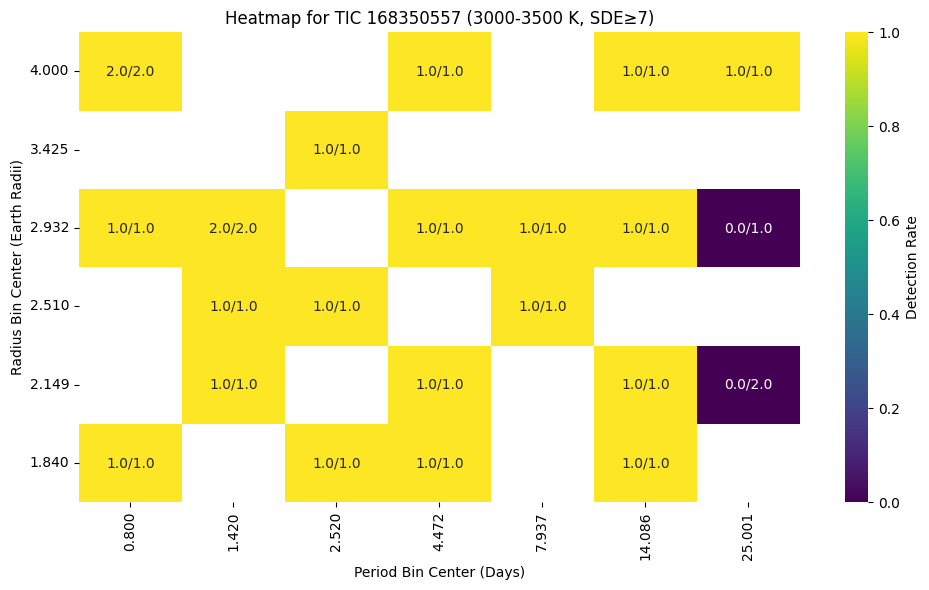

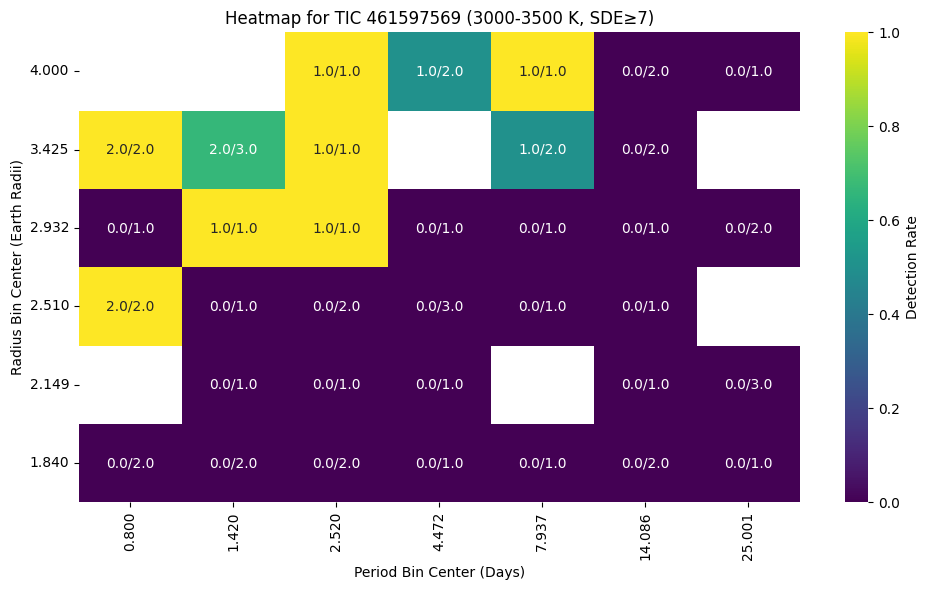

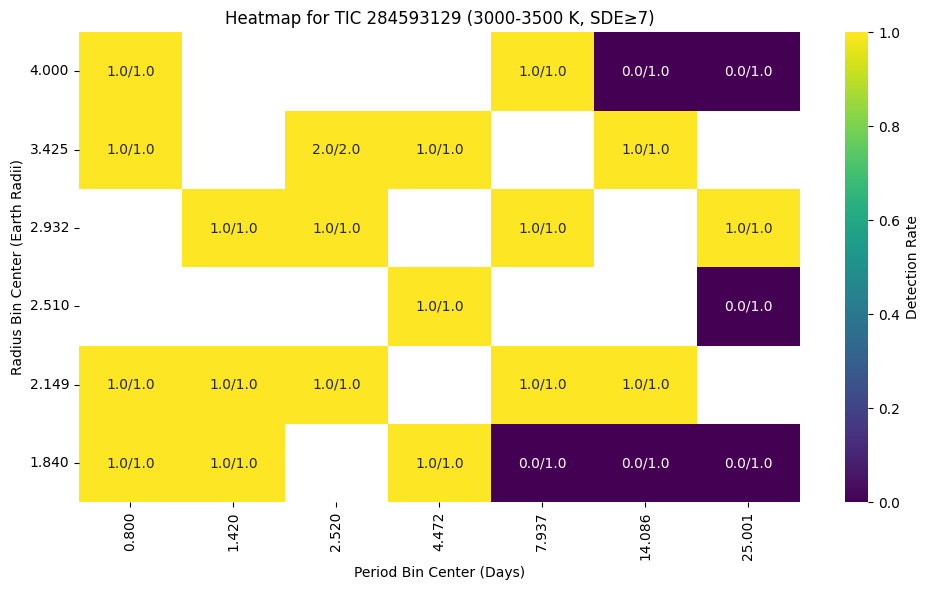

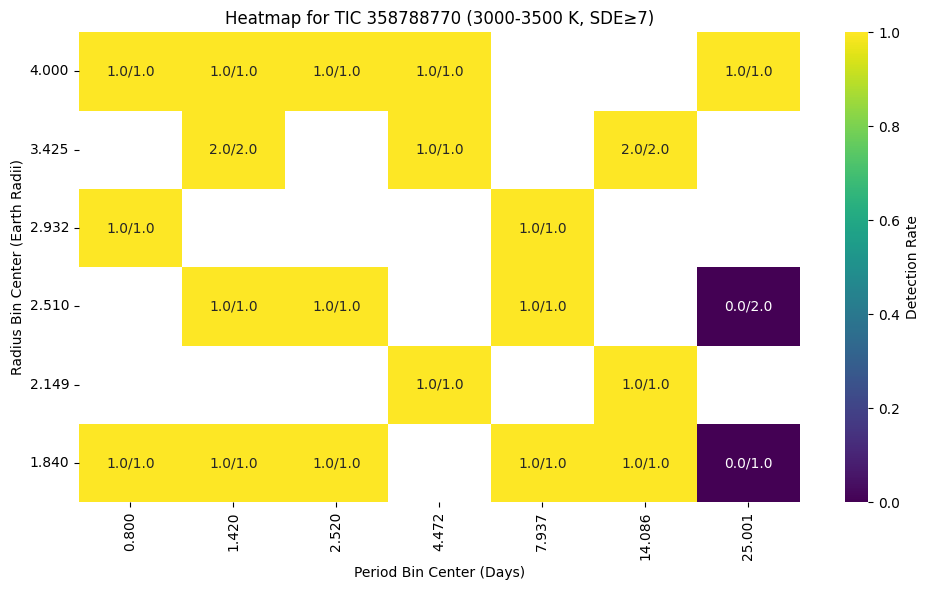

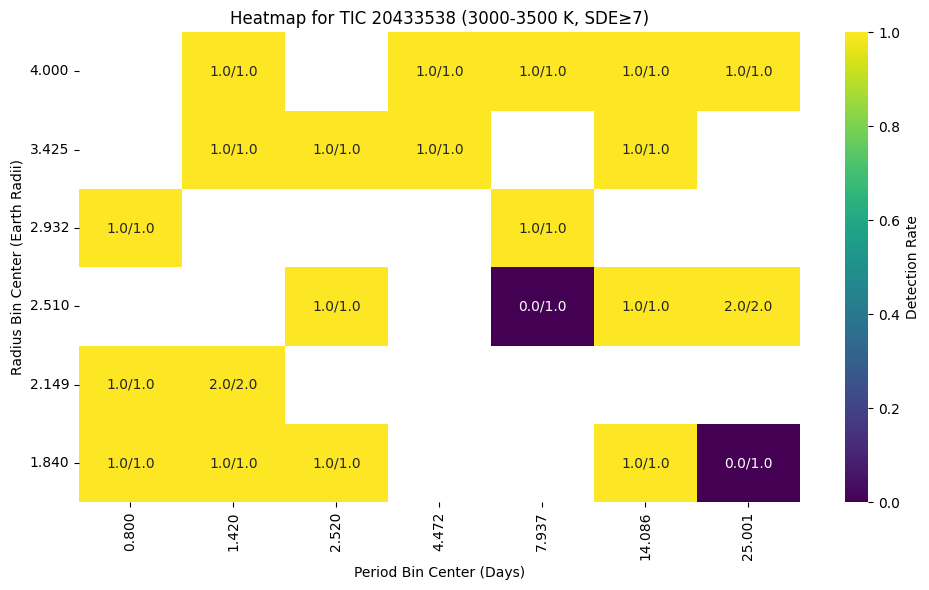

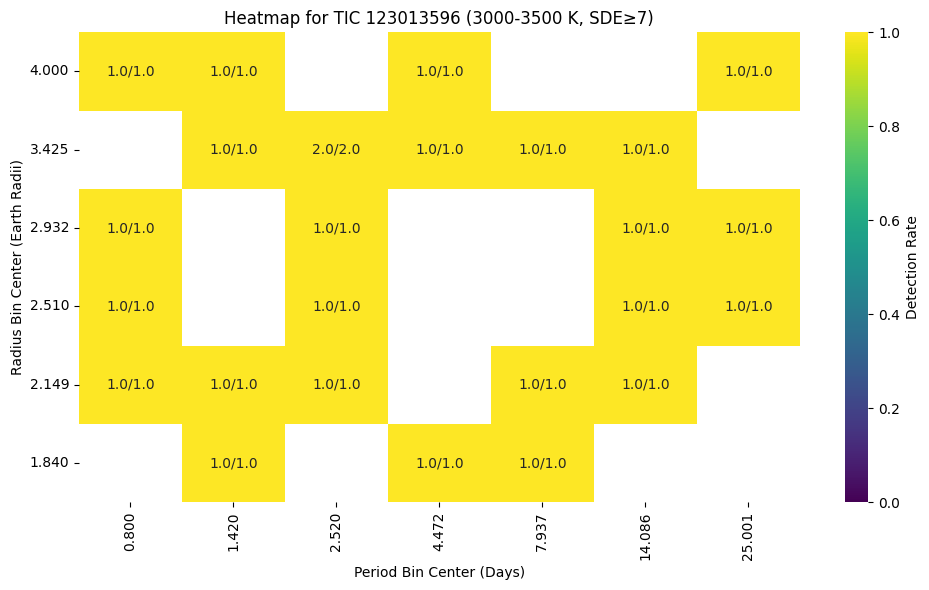

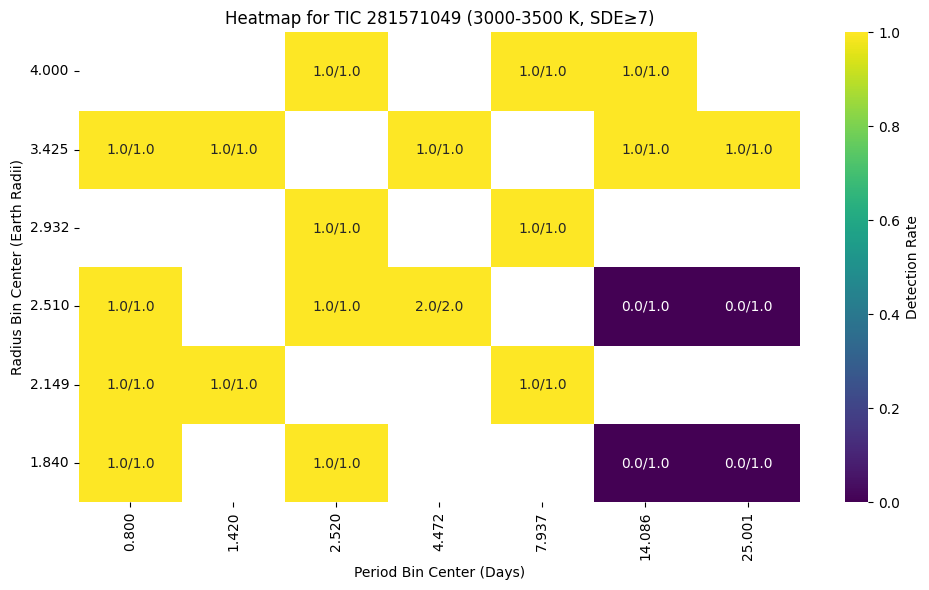

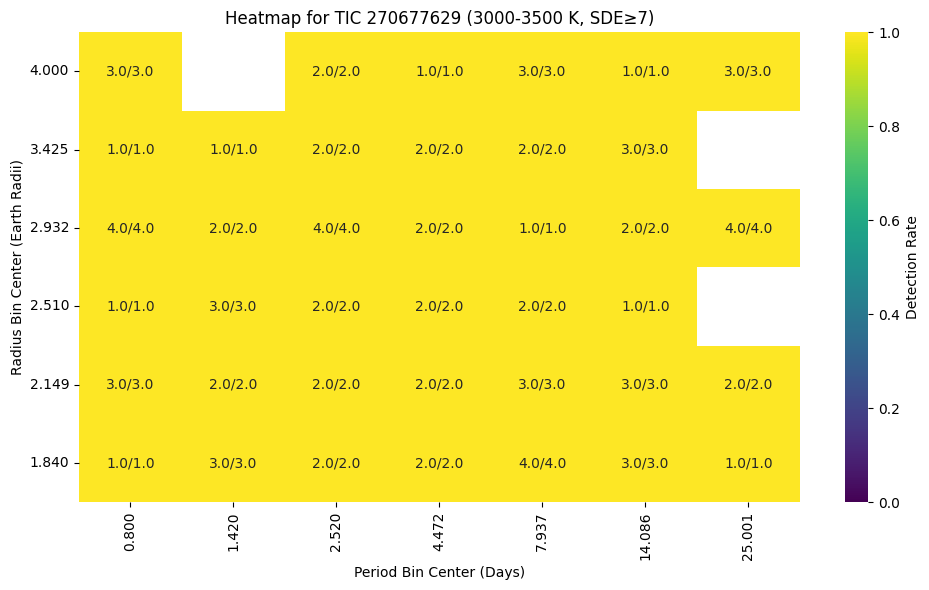

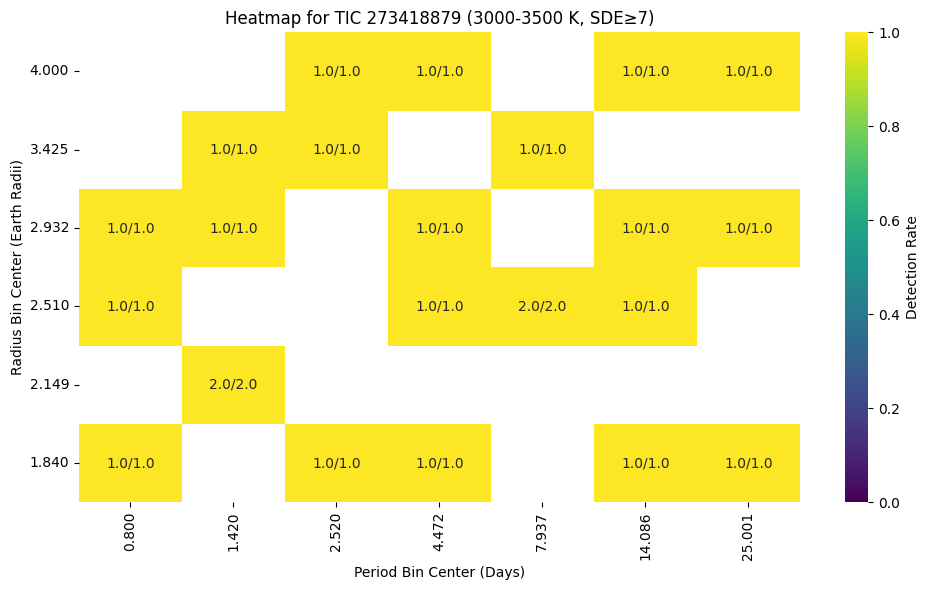

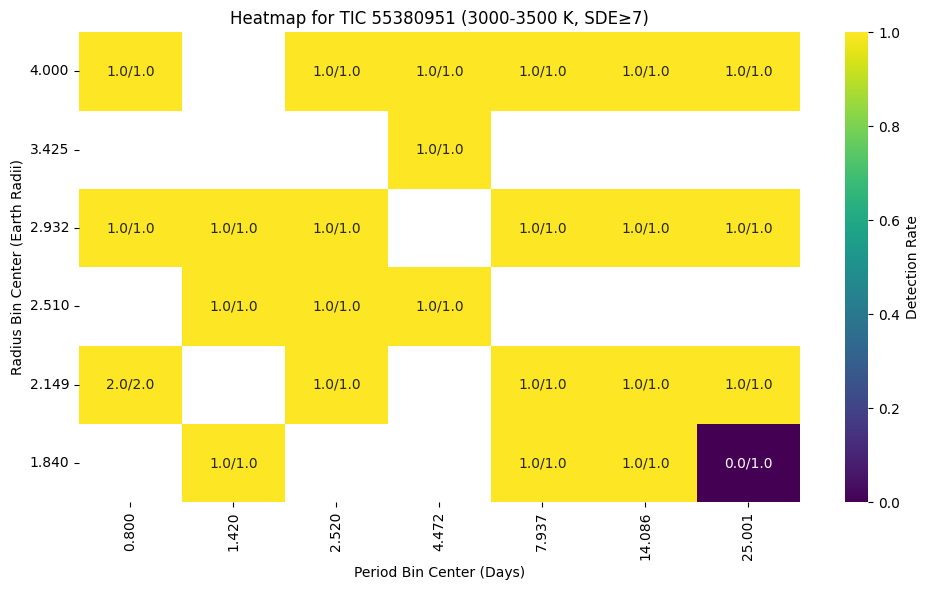

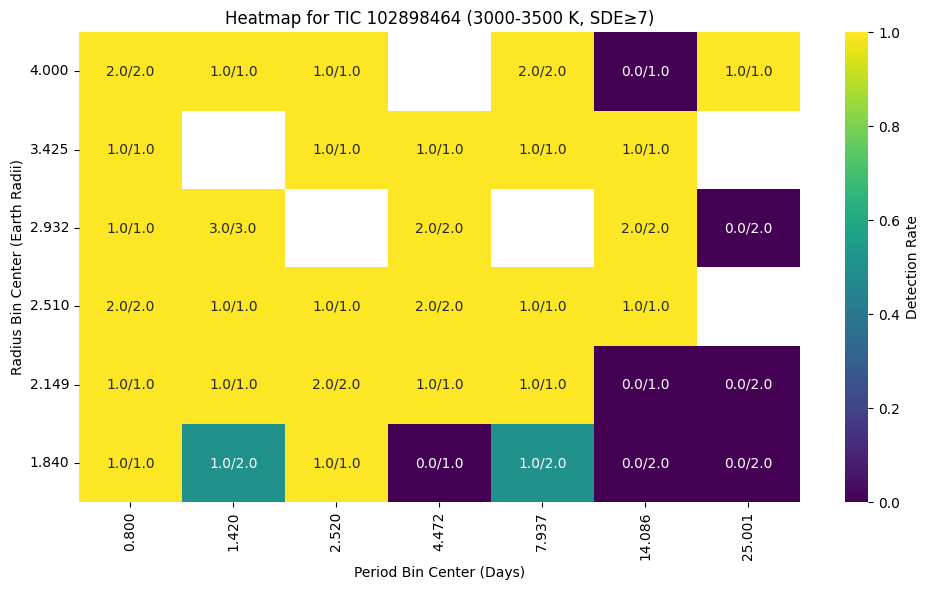

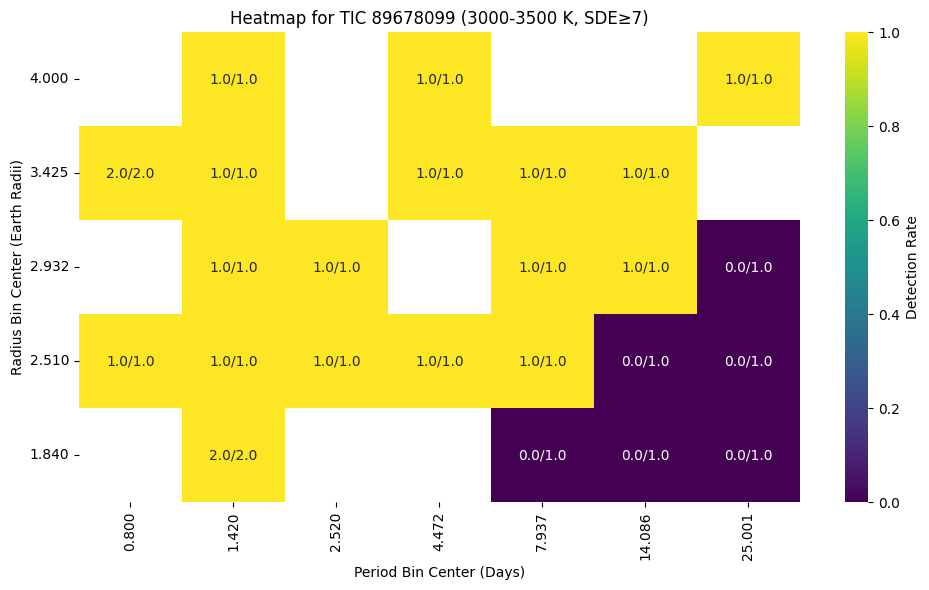

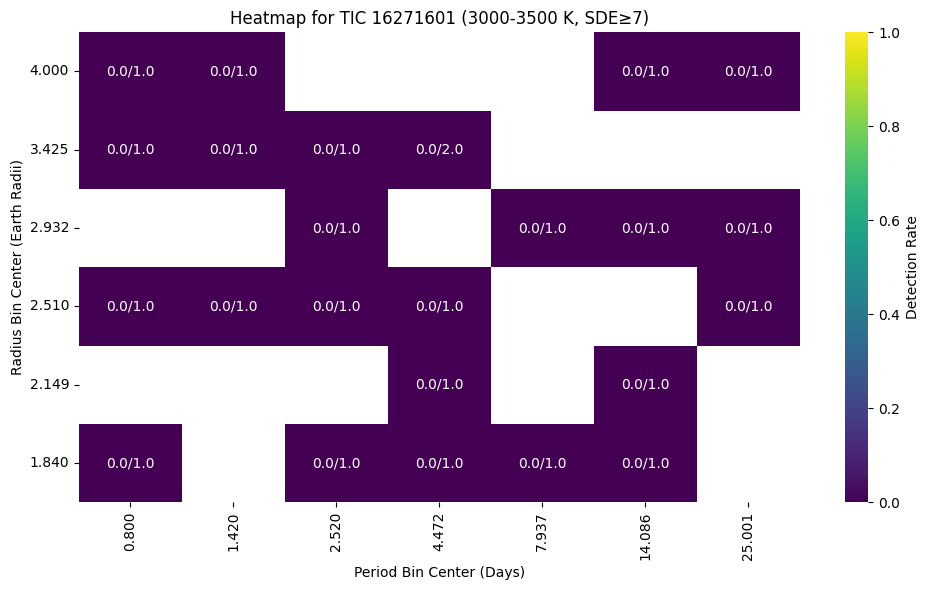

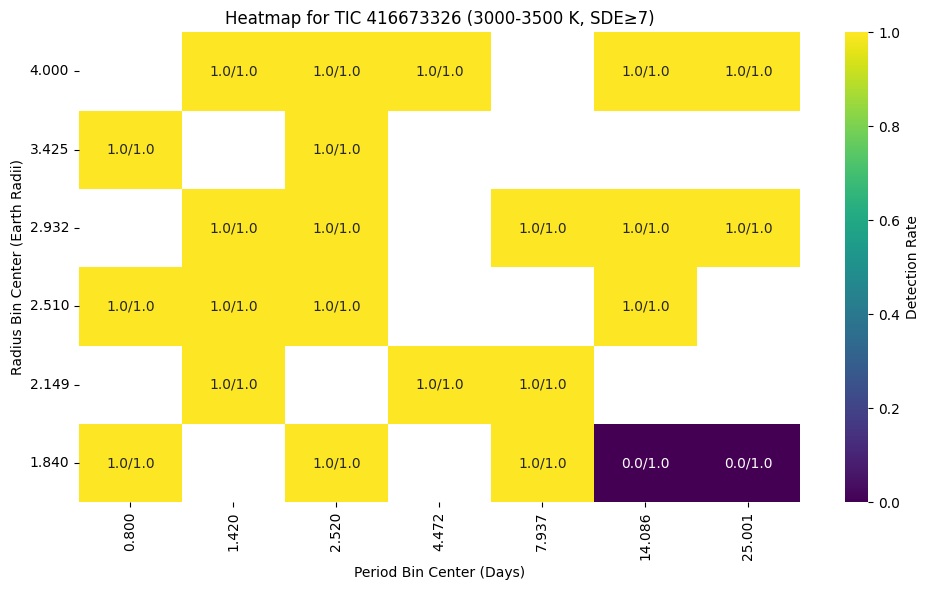

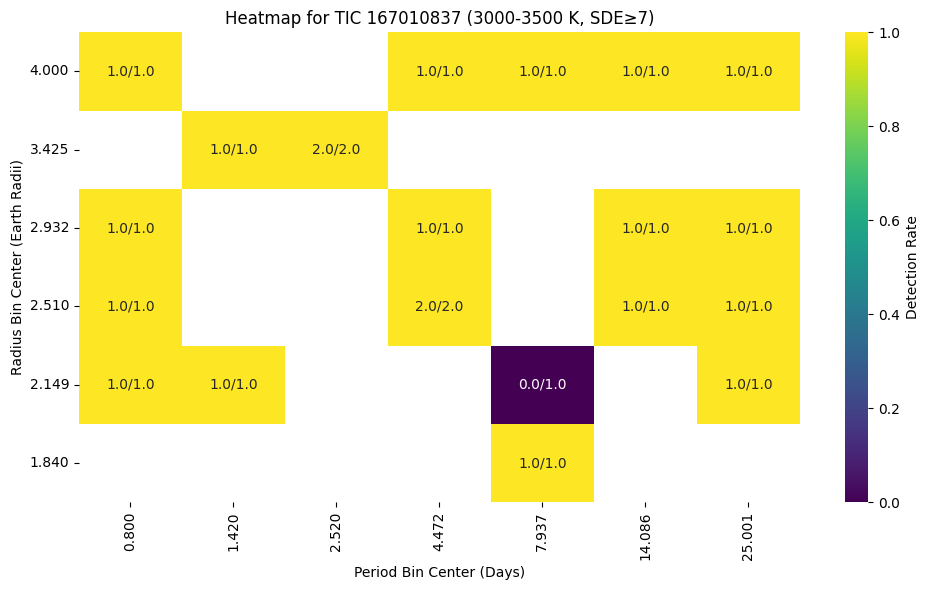

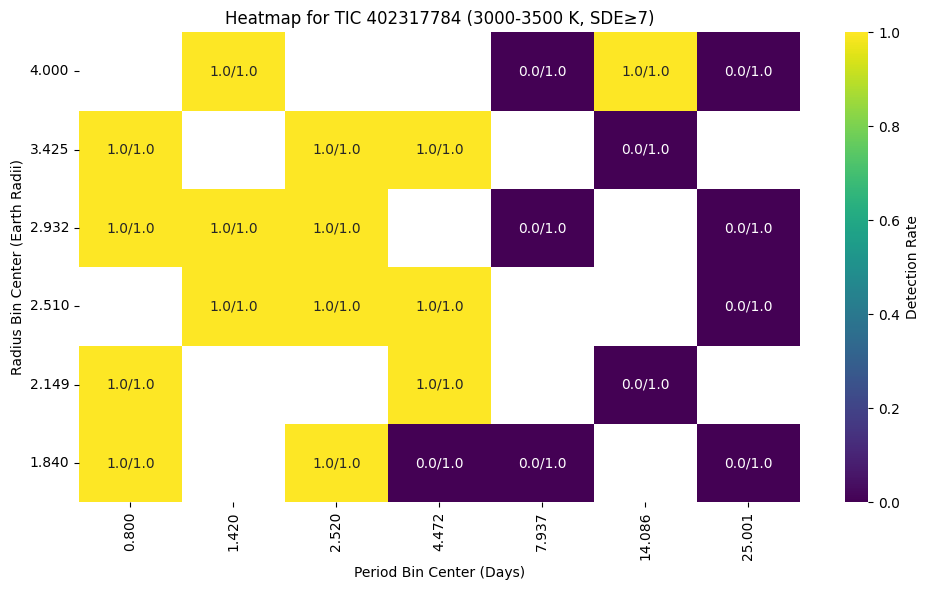

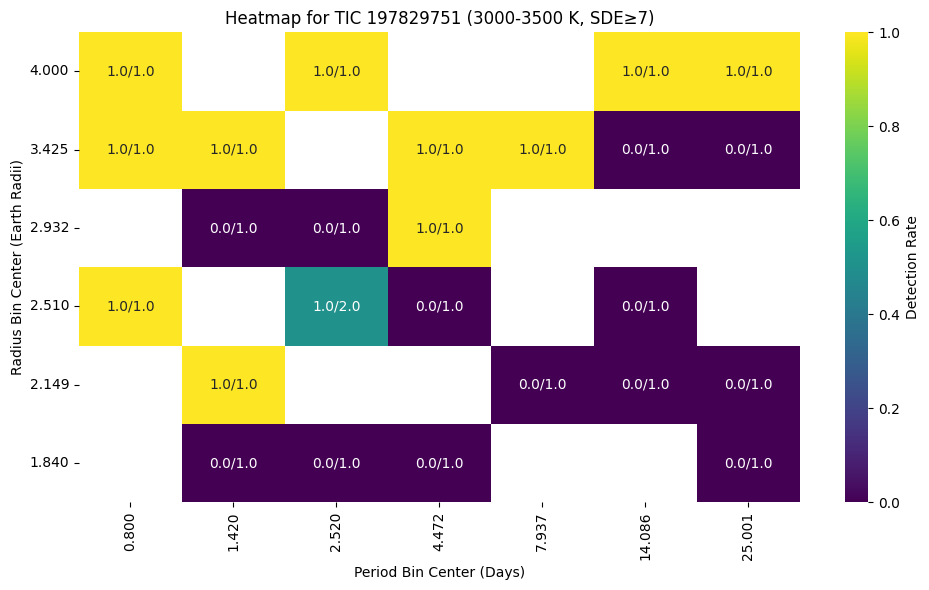

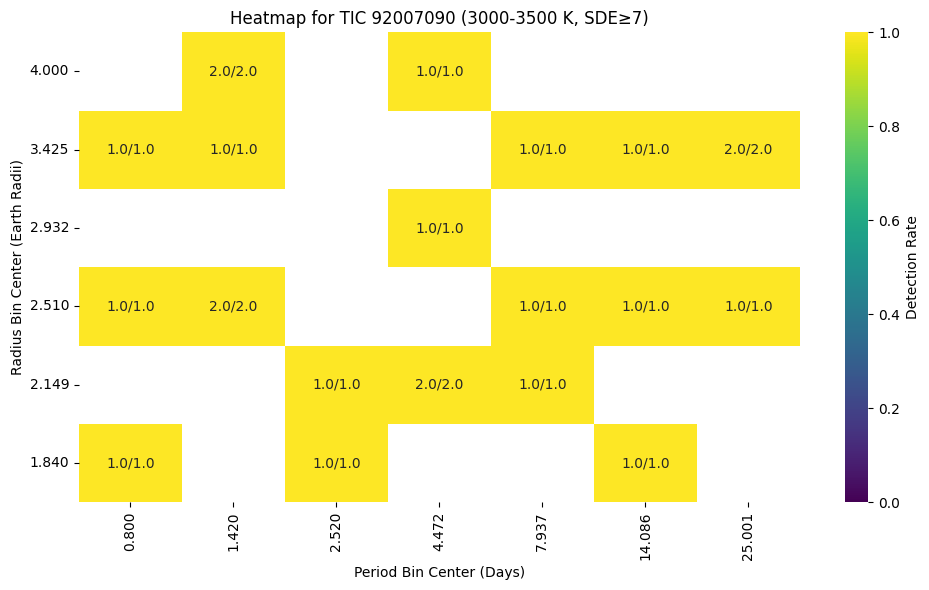

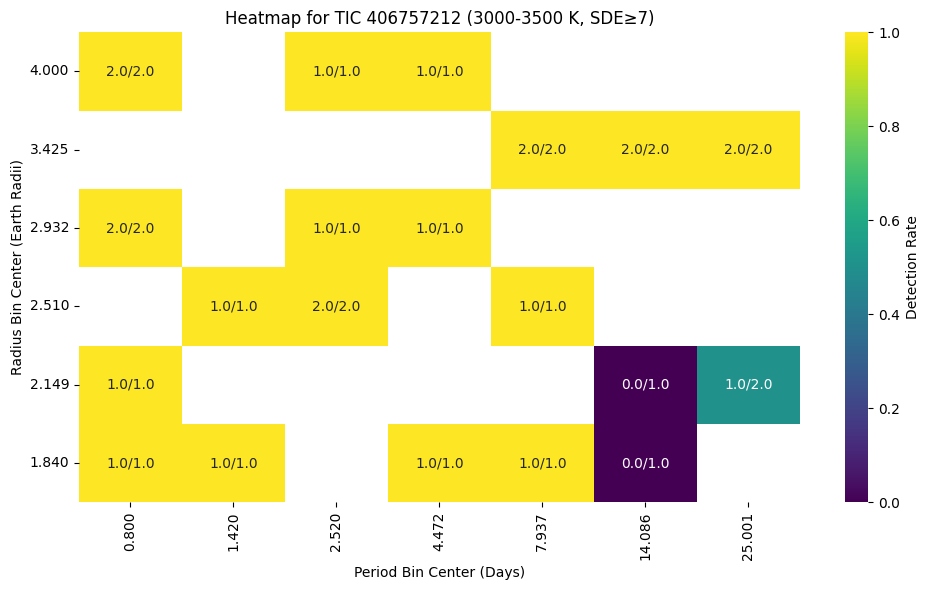

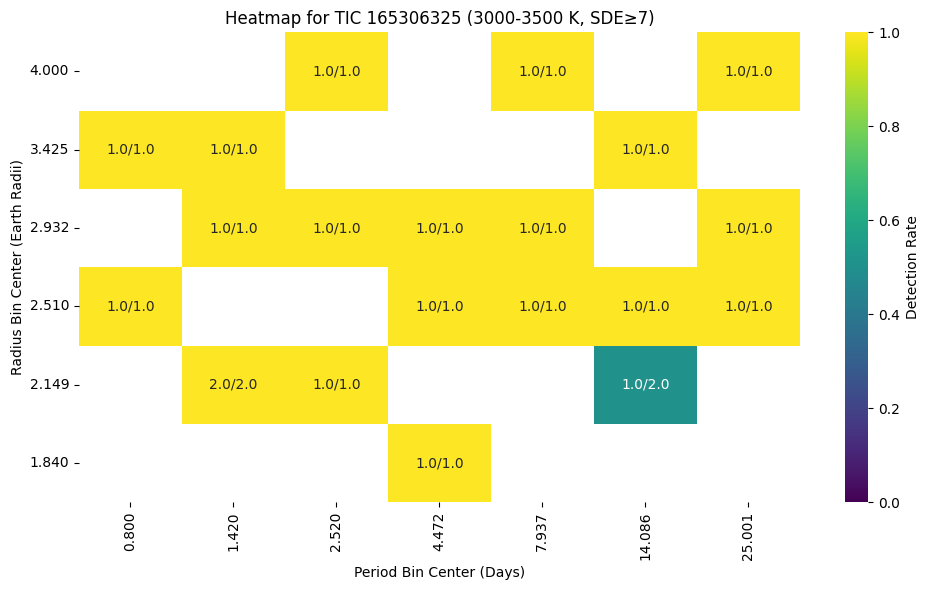

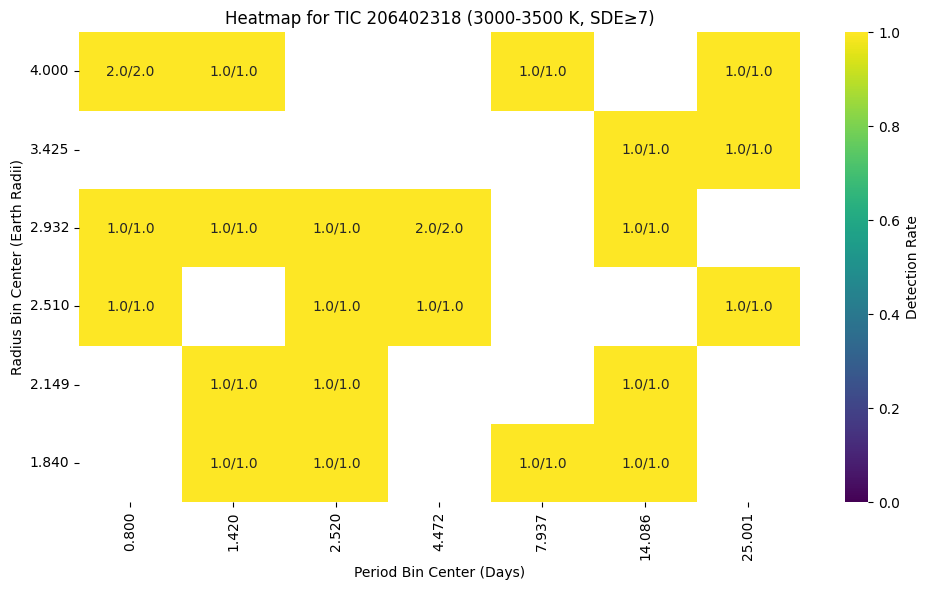

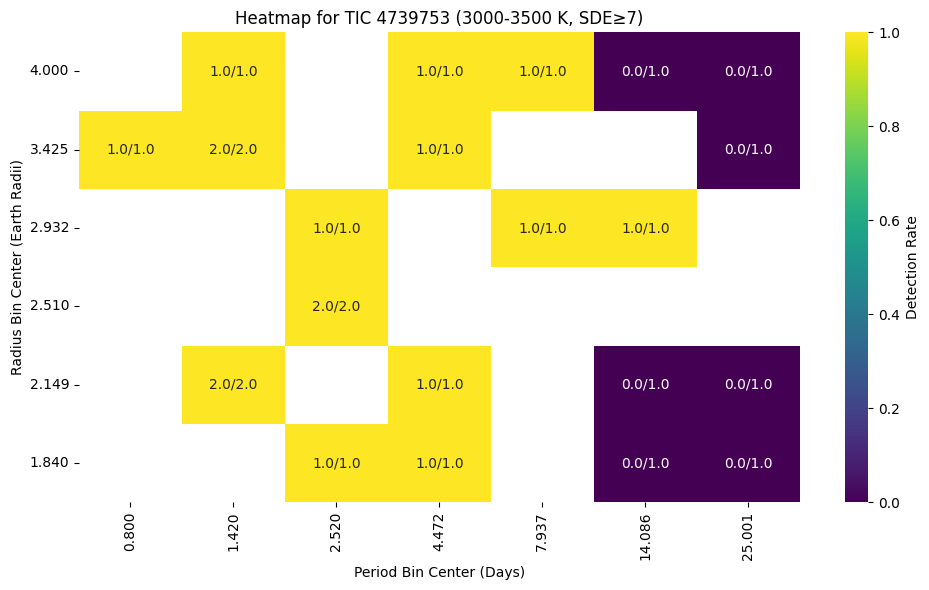

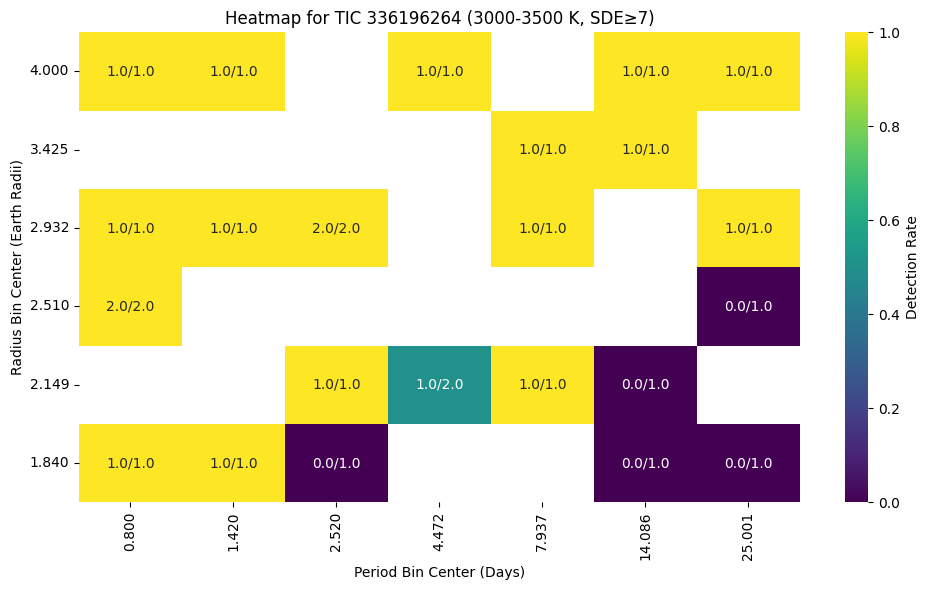

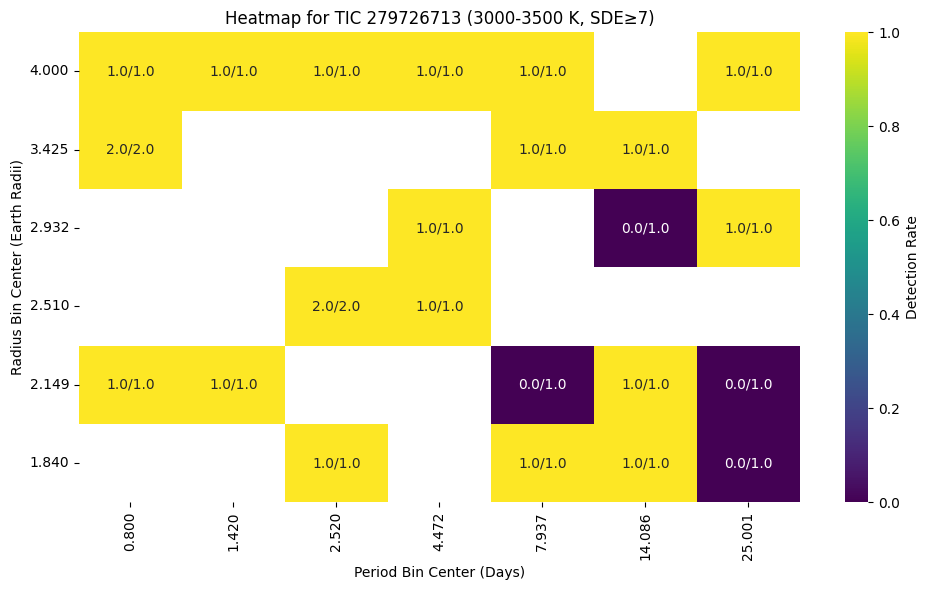

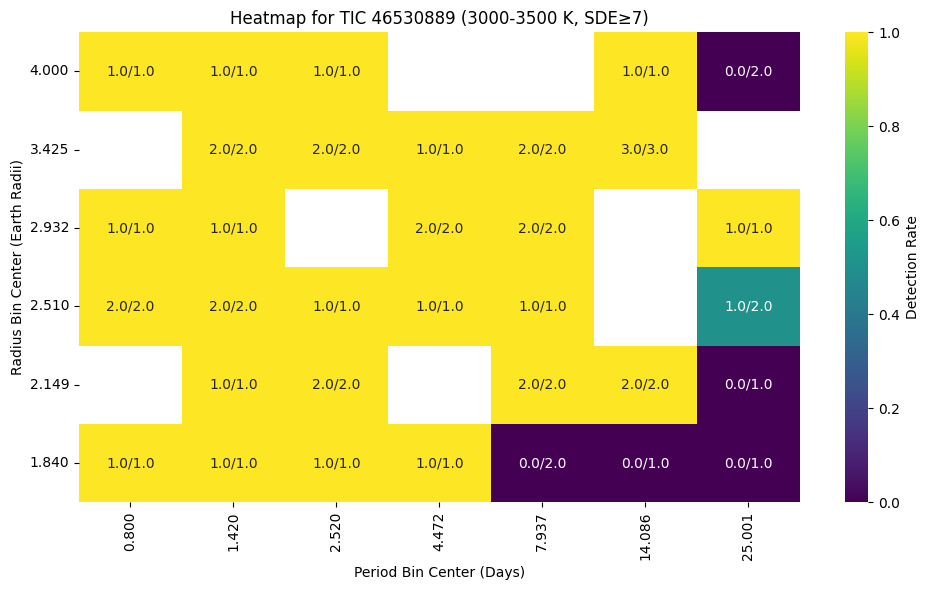

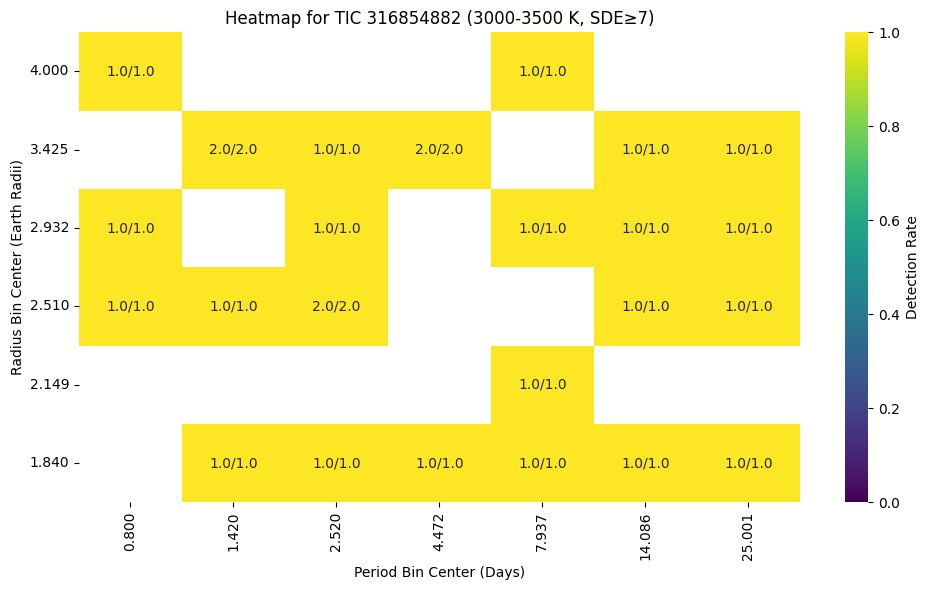

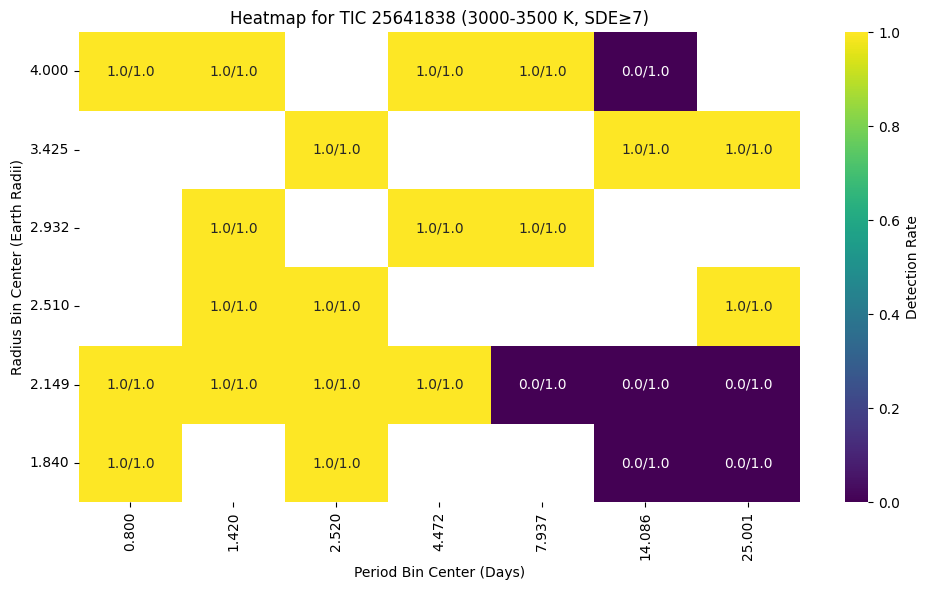

KeyboardInterrupt: 

In [1]:
import os
import glob
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

def calc_geometric_transit_probability(df):
    # Cross-match with CTL.csv to add stellar mass
    ctl_df = pd.read_csv('./take_two_stellar_params_CTL.csv')
    df = df.copy()

    # Clean TIC column in both dataframes to ensure matching
    df['TIC_clean'] = df['TIC'].str.replace('TIC ', '')
    ctl_df['TIC_clean'] = ctl_df['id'].astype(str).str.replace('TIC ', '')

    # Merge to add stellar mass
    df = df.merge(
        ctl_df[['TIC_clean', 'MASS']], 
        on='TIC_clean', 
        how='left'
    ).rename(columns={'MASS': 'Stellar Mass'})

    # Drop the temporary TIC_clean column
    df = df.drop('TIC_clean', axis=1)

    # Check for missing stellar masses and remove them
    missing_mass = df['Stellar Mass'].isna().sum()
    print(f"Removing {missing_mass} rows with missing stellar mass")
    df = df.dropna(subset=['Stellar Mass'])
    print(f"Dataframe size after removal: {len(df)} rows")

    # Calculate transit probability using actual stellar mass (vectorized)
    R_star = df['Stellar Radius'] * 6.96e8  # Solar radii to meters
    R_planet = df['True Radius (Earth Radii)'] * 6.371e6  # Earth radii to meters
    P = df['True Period (Days)'] * 86400  # Days to seconds
    M_star = df['Stellar Mass'] * 1.989e30  # Solar masses to kg
    G = 6.67430e-11  # Gravitational constant in m³/(kg·s²)

    a = ((P**2 * G * M_star) / (4 * np.pi**2))**(1/3)  # Semi-major axis in meters
    df['Transit Probability'] = (R_star + R_planet) / a

    return df

def filter_out_false_positives(df, sde_threshold):
    false_positive_df = pd.read_csv('/Users/danayaptangco/local_code/Mulders/main_proj/tess_demographics/gen_heatmaps/rec_only/rec_results/take_two_CTL_TLS_recovery.csv')

    rows_to_keep = []
    false_positive_count = 0

    for idx, row in df.iterrows():
        tic = row['TIC']
        true_period = float(row['True Period (Days)'])
        
        # Check if this TIC exists in false positives data
        fp_row = false_positive_df[false_positive_df['TIC'] == tic]
        
        is_false_positive = False
        
        # If we found matching TIC in false positive data
        if len(fp_row) > 0:
            try:
                # Parse false positive periods and SDE arrays
                fp_periods = fp_row['TLS Periods array'].iloc[0].replace('[', '').replace(']', '').split()
                fp_periods = [float(p) for p in fp_periods]
                fp_sde = fp_row['TLS SDE > 7 array'].iloc[0].replace('[', '').replace(']', '').split()
                fp_sde = [float(s) for s in fp_sde]
                
                # Get periods above threshold from false positives
                fp_periods_above_threshold = [p for p, s in zip(fp_periods, fp_sde) if s > sde_threshold]
                
                # Check if any false positive periods match our true period or its aliases
                aliases = [true_period, true_period/2, true_period*2, true_period/3, true_period*3]
                is_false_positive = any(0.999 * alias < fp_p < 1.001 * alias 
                                    for fp_p in fp_periods_above_threshold 
                                    for alias in aliases)

                # SET TO 0 method
                if any(any(0.999 * alias < fp_p < 1.001 * alias for alias in aliases) for fp_p in fp_periods_above_threshold):
                    df.loc[idx, 'TLS Periods array'] = '[]'
                    df.loc[idx, 'TLS SDE > 7 array'] = '[]'
                    false_positive_count += 1
            except:
                pass
        
        # Keep the row only if it's NOT a false positive
        if is_false_positive == False:
            rows_to_keep.append(idx)
        # SET TO 0 method
        elif is_false_positive == True:
            rows_to_keep.append(idx)

    # Filter the dataframe
    df_filtered = df.loc[rows_to_keep].reset_index(drop=True)
    print(f"False positive cells removed: {false_positive_count}")

    return df_filtered

def individual_tic_heatmaps(df, sde_threshold, temp_range, periods_bins, radii_bins):
    """
    Generate individual heatmaps for each TIC within a temperature range.
    
    Parameters:
    df: DataFrame with TIC data
    sde_threshold: SDE threshold for detection
    temp_range: tuple (temp_min, temp_max) for stellar temperature filtering
    periods_bins: list of (min, max) tuples for period bins
    radii_bins: list of (min, max) tuples for radius bins
    """
    temp_min, temp_max = temp_range
    
    # Filter based on Stellar Temperature
    temp_lim = (df['Stellar Temperature'] >= temp_min) & (df['Stellar Temperature'] <= temp_max)
    df = df[temp_lim].copy()
    
    # Add geometric transit probability and filter false positives
    df = calc_geometric_transit_probability(df)
    df = filter_out_false_positives(df, sde_threshold)
    
    unique_tics = df['TIC'].unique()
    print(f"Processing {len(unique_tics)} unique TICs in temperature range {temp_min}-{temp_max} K")

    # Calculate bin centers for labeling
    radius_centers = [10**((np.log10(rmin) + np.log10(rmax))/2) for rmin, rmax in radii_bins]
    period_centers = [10**((np.log10(pmin) + np.log10(pmax))/2) for pmin, pmax in periods_bins]

    for tic in unique_tics:
        try:
            # Get all rows for this TIC
            tic_df = pd.DataFrame(columns=['TIC', 'True Radius (Earth Radii)', 'True Period (Days)', 
                                         'Detection', '# trials', 'TLS Periods array', 'TLS SDE > 7 array'])
            tic_rows = df[df['TIC'] == tic]
            
            if tic_rows['True Radius (Earth Radii)'].isnull().all():
                print(f"No valid data for {tic}, skipping...")
                continue
                
            for idx, row in tic_rows.iterrows():
                tic_df = pd.concat([tic_df, pd.DataFrame({
                    'TIC': [tic],
                    'True Radius (Earth Radii)': [row['True Radius (Earth Radii)']],
                    'True Period (Days)': [row['True Period (Days)']],
                    'Detection': [row['Detection']],
                    '# trials': [row['# trials']],
                    'TLS Periods array': [row['TLS Periods array']],
                    'TLS SDE > 7 array': [row['TLS SDE > 7 array']]
                })], ignore_index=True)

            # Create heatmap for this TIC
            heatmap_df = pd.DataFrame(columns=['radius_bin_center', 'period_bin_center', 'Detection'])
            
            for index, row in tic_df.iterrows():
                true_period = float(row['True Period (Days)'])
                true_radius = float(row['True Radius (Earth Radii)'])
                
                # Find which bin this period and radius fall into
                period_bin_center = None
                for i, (pmin, pmax) in enumerate(periods_bins):
                    if pmin <= true_period < pmax:
                        period_bin_center = period_centers[i]
                        break
                
                radius_bin_center = None
                for i, (rmin, rmax) in enumerate(radii_bins):
                    if rmin <= true_radius < rmax:
                        radius_bin_center = radius_centers[i]
                        break
                
                # Skip if outside bin ranges
                if period_bin_center is None or radius_bin_center is None:
                    continue
                
                periods = row['TLS Periods array']
                try:
                    periods = periods.replace('[', '').replace(']', '').split()
                except:
                    continue
                periods = [float(p) for p in periods]
                
                sde = row['TLS SDE > 7 array']
                try:
                    sde = sde.replace('[', '').replace(']', '').split()
                except:
                    continue
                sde = [float(s) for s in sde]
                
                periods_sde_tuple = zip(periods, sde)
                periods_above_threshold = np.array([], dtype=float)
                
                for periods_val, sde_val in periods_sde_tuple:
                    if sde_val > sde_threshold:
                        periods_above_threshold = np.append(periods_above_threshold, periods_val)
                
                # Check if true_period is close to any period above threshold (within 1% relative difference)
                aliases = [true_period, true_period / 2, true_period * 2, true_period / 3, true_period * 3]
                
                if any(0.999 * alias < hp < 1.001 * alias for hp in periods_above_threshold for alias in aliases):
                    detection = 1
                else:
                    detection = 0
                    
                heatmap_df = pd.concat([heatmap_df, pd.DataFrame({
                    'radius_bin_center': [radius_bin_center],
                    'period_bin_center': [period_bin_center],
                    'Detection': [detection] 
                })], ignore_index=True)

            # Convert Detection column to numeric for averaging
            heatmap_df['Detection'] = pd.to_numeric(heatmap_df['Detection'])
            
            # Group by bin centers, counting detections and total trials
            heatmap_counts = heatmap_df.groupby(['radius_bin_center', 'period_bin_center']).agg(
                detections=('Detection', 'sum'),
                trials=('Detection', 'count')
            ).reset_index()

            # Numeric detection rate for coloring
            heatmap_counts['detection_rate'] = heatmap_counts['detections'] / heatmap_counts['trials']

            # Pivot for heatmap coloring
            heatmap_pivot = heatmap_counts.pivot(
                index='radius_bin_center',
                columns='period_bin_center',
                values='detection_rate'
            )

            # Create annotation matrix with "detections/trials" strings
            annot_matrix = heatmap_counts.pivot(
                index='radius_bin_center',
                columns='period_bin_center',
                values='detections'
            ).astype(str) + "/" + heatmap_counts.pivot(
                index='radius_bin_center',
                columns='period_bin_center',
                values='trials'
            ).astype(str)

            plt.figure(figsize=(10, 6))
            sns.heatmap(
                heatmap_pivot,
                annot=annot_matrix,
                fmt='',  # show strings exactly
                cmap='viridis',
                cbar_kws={'label': 'Detection Rate'},
                vmin=0, vmax=1
            )

            plt.gca().invert_yaxis()
            
            # Format axis labels to 3 decimal places
            ax = plt.gca()
            ax.set_xticklabels([f'{float(label.get_text()):.3f}' if label.get_text() else '' 
                               for label in ax.get_xticklabels()])
            ax.set_yticklabels([f'{float(label.get_text()):.3f}' if label.get_text() else '' 
                               for label in ax.get_yticklabels()])
            
            plt.title(f'Heatmap for {tic} ({temp_min}-{temp_max} K, SDE≥{sde_threshold})')
            plt.xlabel('Period Bin Center (Days)')
            plt.ylabel('Radius Bin Center (Earth Radii)')
            plt.tight_layout()
            plt.show()

        except Exception as e:
            print(f"An error for {tic} occurred: {e}")

# Example usage:
# Load data
csv_files = glob.glob('./take_two_tls_results_per_tic/*')
df_list = [pd.read_csv(f) for f in csv_files]
df = pd.concat(df_list, ignore_index=True)
df = df[['TIC', 'True Radius (Earth Radii)', 'True Period (Days)', 'Detection', '# trials', 
         'TLS Periods array', 'TLS SDE > 7 array', 'Stellar Radius', 'Stellar Temperature']]
df = df.drop_duplicates(subset=['TIC', 'True Radius (Earth Radii)', 'True Period (Days)', '# trials'])

#######################
#Binning
# Log-spaced list between 1.4 and 5 (inclusive), in log10 space
radii_centers = np.logspace(np.log10(1.84), np.log10(4), num=6)
# Log-spaced list between 0.7 and 25 (inclusive), in log10 space
periods_centers = np.logspace(np.log10(0.8), np.log10(25), num=7)

# Convert radii_centers and periods_centers to floats with up to 3 decimals
radii_centers = [float(f"{v:.3f}") for v in radii_centers]
periods_centers = [float(f"{v:.3f}") for v in periods_centers]


# Generate bin edges from centers
periods_log = np.log10(periods_centers)
log_step = periods_log[1] - periods_log[0]
period_bin_edges = [10**(periods_log[0] - log_step/2)]
period_bin_edges.extend([10**((periods_log[i] + periods_log[i+1])/2) for i in range(len(periods_log)-1)])
period_bin_edges.append(10**(periods_log[-1] + log_step/2))
periods_bins = [(period_bin_edges[i], period_bin_edges[i+1]) for i in range(len(period_bin_edges)-1)]

radii_log = np.log10(radii_centers)
log_step = radii_log[1] - radii_log[0]
radius_bin_edges = [10**(radii_log[0] - log_step/2)]
radius_bin_edges.extend([10**((radii_log[i] + radii_log[i+1])/2) for i in range(len(radii_log)-1)])
radius_bin_edges.append(10**(radii_log[-1] + log_step/2))
radii_bins = [(radius_bin_edges[i], radius_bin_edges[i+1]) for i in range(len(radius_bin_edges)-1)]

print("Period bins:", periods_bins)
print("Radius bins:", radii_bins)


##########
# Run function for a specific temperature range
sde_threshold = 7
temp_range = (3000, 3500)  # Example temperature range
individual_tic_heatmaps(df, sde_threshold, temp_range, periods_bins=periods_bins, radii_bins=radii_bins)

Period bins: [(0.602879601886859, 1.0247419187288085), (1.0247419187288085, 1.7422376416551217), (1.7422376416551217, 2.962555653485686), (2.962555653485686, 5.037847754746068), (5.037847754746068, 8.567765753100398), (8.567765753100398, 14.570072065710583), (14.570072065710583, 24.771115083775257)]
Radius bins: [(1.8, 2.056223979157517), (2.056223979157517, 2.348920584701318), (2.348920584701318, 2.6832815729997477), (2.6832815729997477, 3.0652377295742124), (3.0652377295742124, 3.501564067427134), (3.501564067427134, 4.0)]
Problem files: []
Duplicates dropped: 0
Len of df after dropping duplicates: 39746
Number of unique TICs: 791

Removing 0 rows with missing stellar mass
Dataframe size after removal: 2728 rows
False positive cells: 37


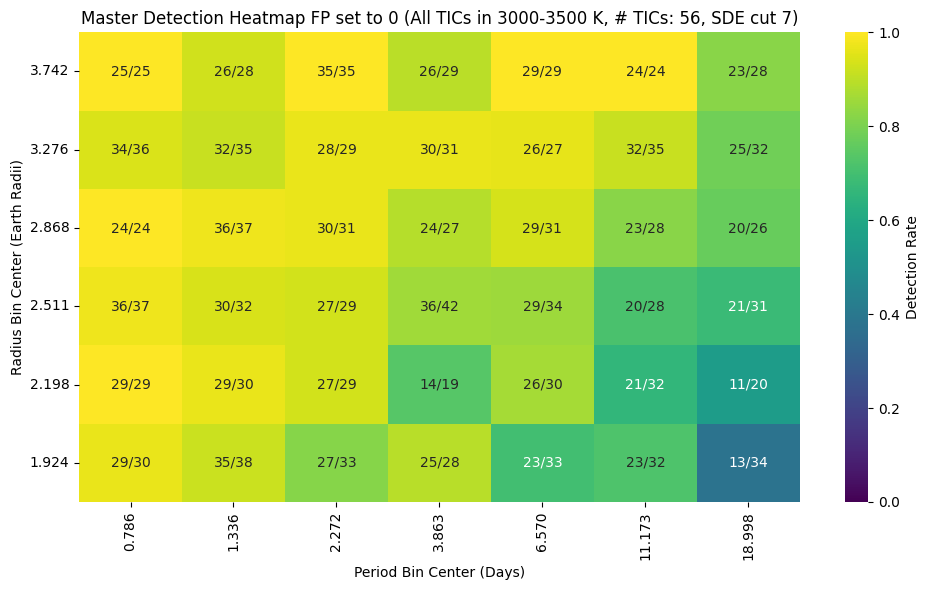

Removing 0 rows with missing stellar mass
Dataframe size after removal: 3683 rows
False positive cells: 51


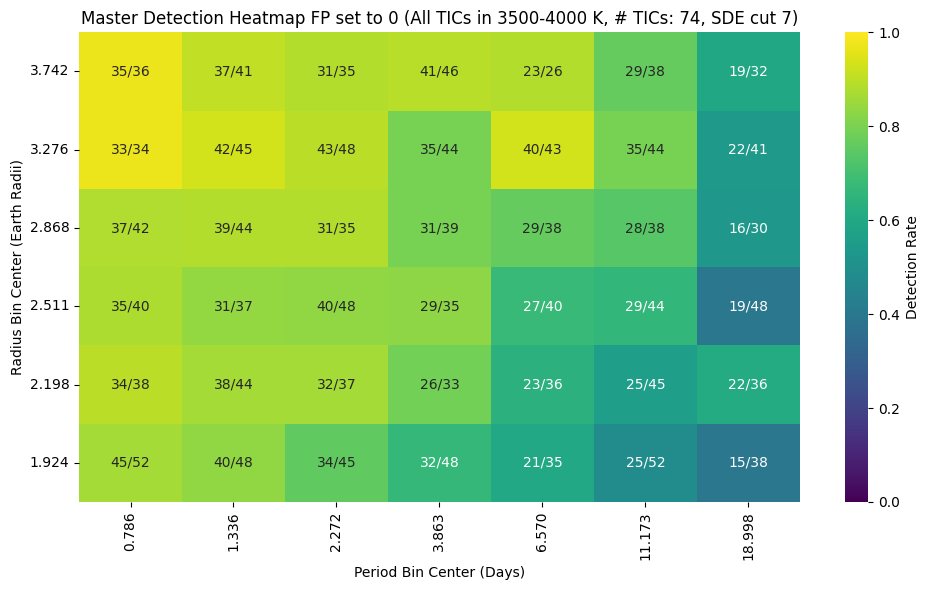

Removing 0 rows with missing stellar mass
Dataframe size after removal: 3077 rows
False positive cells: 48


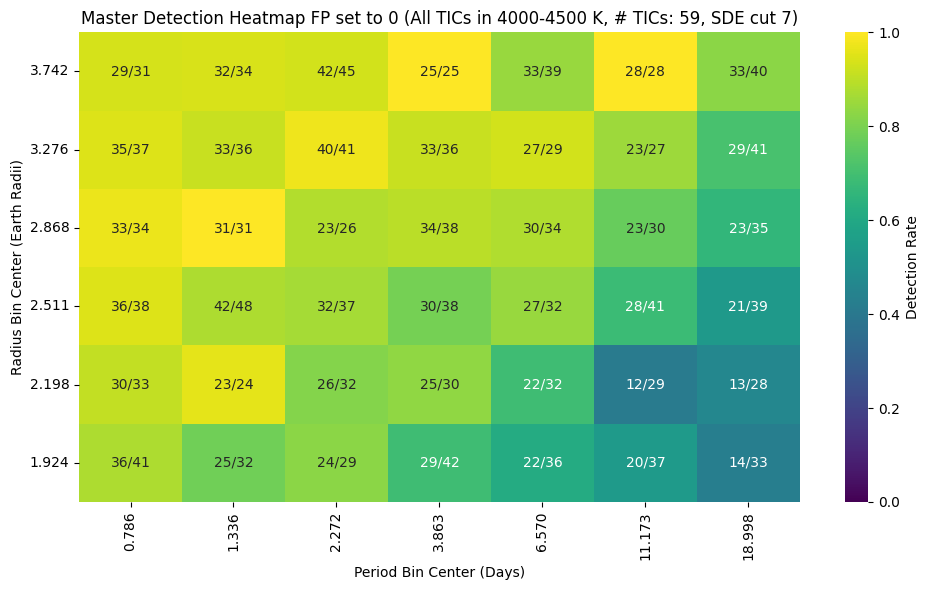

Removing 0 rows with missing stellar mass
Dataframe size after removal: 4322 rows
False positive cells: 56


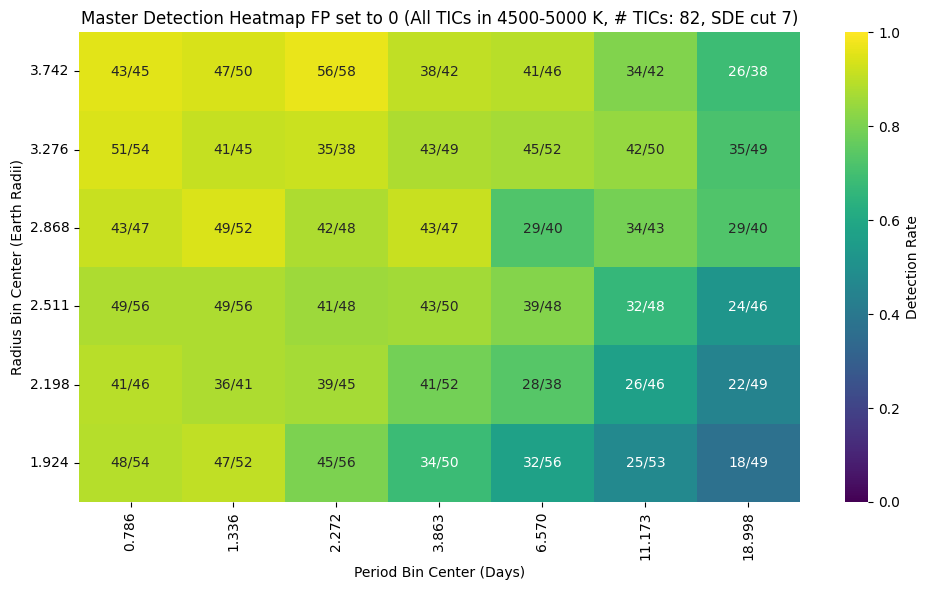

Removing 0 rows with missing stellar mass
Dataframe size after removal: 7305 rows
False positive cells: 101


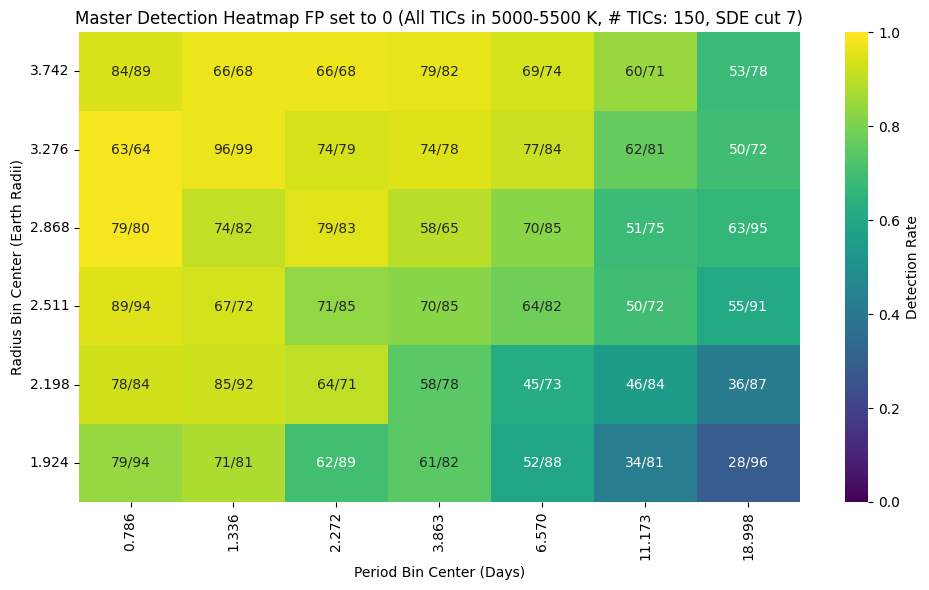

Removing 0 rows with missing stellar mass
Dataframe size after removal: 10516 rows
False positive cells: 166


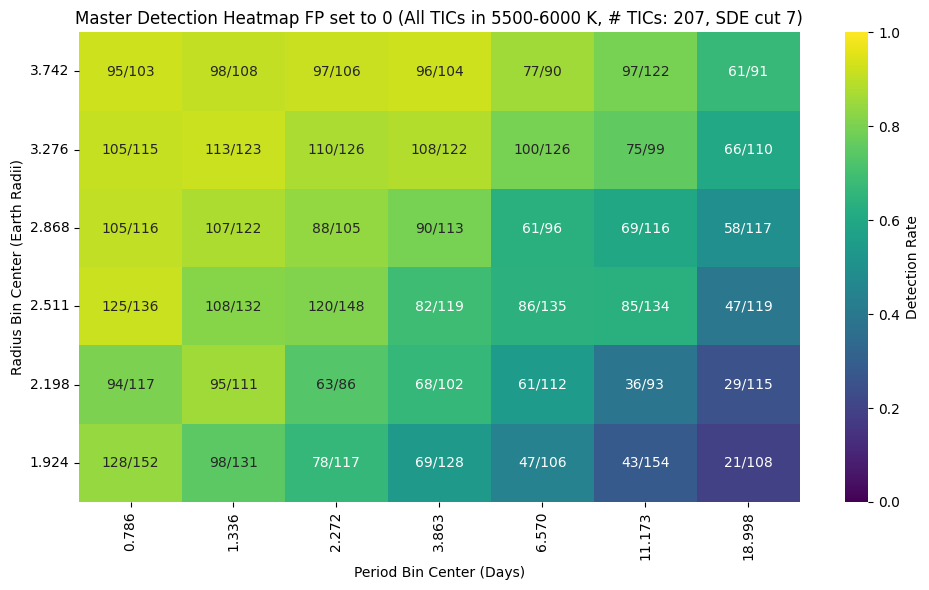

Removing 0 rows with missing stellar mass
Dataframe size after removal: 5999 rows
False positive cells: 77


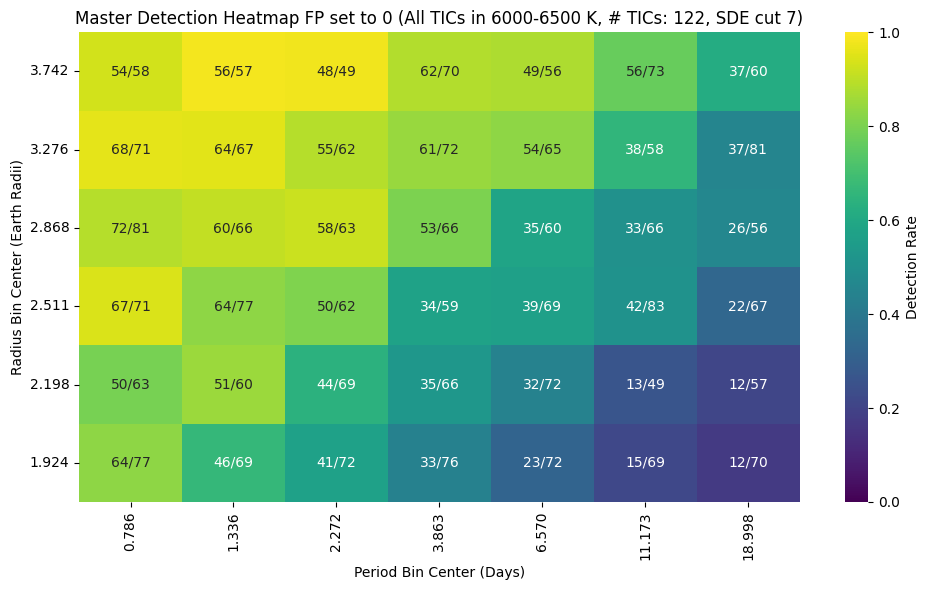

Removing 0 rows with missing stellar mass
Dataframe size after removal: 2158 rows
False positive cells: 37


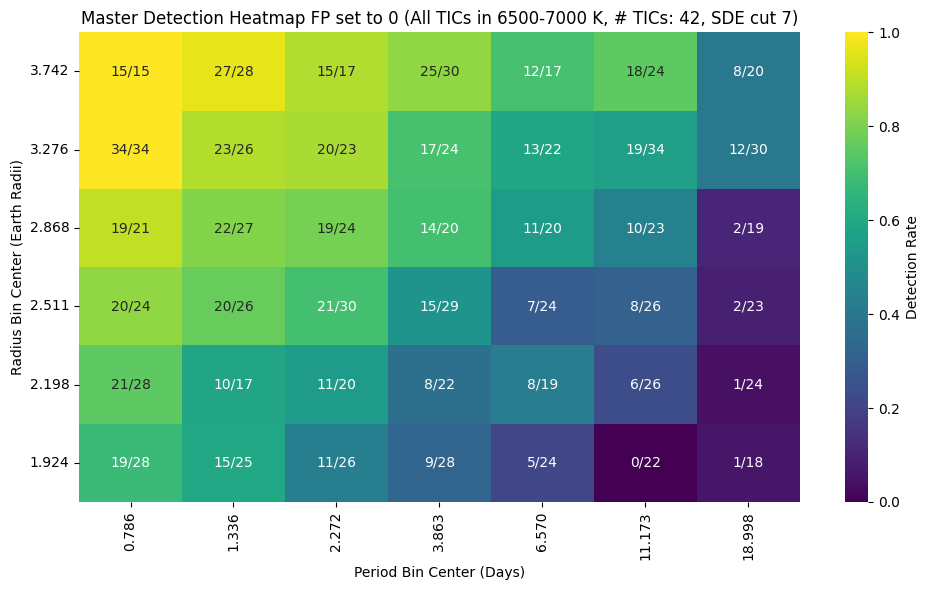

In [2]:
import os
import glob
import pandas as pd
import seaborn as sns
import numpy as np

import matplotlib.pyplot as plt
from scipy.interpolate import griddata

def calc_geometric_transit_probability(df):
    # Cross-match with CTL.csv to add stellar mass
    ctl_df = pd.read_csv('./take_two_stellar_params_CTL.csv')
    df = df.copy()

    # Clean TIC column in both dataframes to ensure matching
    df['TIC_clean'] = df['TIC'].str.replace('TIC ', '')
    ctl_df['TIC_clean'] = ctl_df['id'].astype(str).str.replace('TIC ', '')

    # Merge to add stellar mass
    df = df.merge(
        ctl_df[['TIC_clean', 'MASS']], 
        on='TIC_clean', 
        how='left'
    ).rename(columns={'MASS': 'Stellar Mass'})

    # Drop the temporary TIC_clean column
    df = df.drop('TIC_clean', axis=1)
    #print(df)


    # Check for missing stellar masses and remove them
    missing_mass = df['Stellar Mass'].isna().sum()
    print(f"Removing {missing_mass} rows with missing stellar mass")
    df = df.dropna(subset=['Stellar Mass'])
    print(f"Dataframe size after removal: {len(df)} rows")

    # Calculate transit probability using actual stellar mass (vectorized)
    R_star = df['Stellar Radius'] * 6.96e8  # Solar radii to meters
    R_planet = df['True Radius (Earth Radii)'] * 6.378e6  # Earth radii to meters
    P = df['True Period (Days)'] * 86400  # Days to seconds
    M_star = df['Stellar Mass'] * 1.989e30  # Solar masses to kg
    G = 6.67430e-11  # Gravitational constant in m³/(kg·s²)

    a = ((P**2 * G * M_star) / (4 * np.pi**2))**(1/3)  # Semi-major axis in meters
    df['Transit Probability'] = (R_star + R_planet) / a
    return df


def transit_probability_heatmap(df, temp_range, periods_bins, radii_bins):
    # temp_range should be like (3000, 3500)
    temp_min, temp_max = temp_range

    # Filter based on Stellar Temperature
    temp_lim = (df['Stellar Temperature'] >= temp_min) & (df['Stellar Temperature'] <= temp_max)
    df = df[temp_lim].copy()

    #########################
    df = calc_geometric_transit_probability(df)
    ########################

    unique_tics = df['TIC'].unique()

    # Calculate bin centers for labeling
    radius_centers = [10**((np.log10(rmin) + np.log10(rmax))/2) for rmin, rmax in radii_bins]
    period_centers = [10**((np.log10(pmin) + np.log10(pmax))/2) for pmin, pmax in periods_bins]

    # Collect all transit probability results here
    all_transit_rows = []

    for tic in unique_tics:
        try:
            tic_rows = df[df['TIC'] == tic]
            if tic_rows['True Radius (Earth Radii)'].isnull().all():
                continue

            for _, row in tic_rows.iterrows():
                true_period = float(row['True Period (Days)'])
                true_radius = float(row['True Radius (Earth Radii)'])
                
                # Find which bin this period and radius fall into
                period_bin_center = None
                for i, (pmin, pmax) in enumerate(periods_bins):
                    if pmin <= true_period < pmax:
                        period_bin_center = period_centers[i]
                        break
                
                radius_bin_center = None
                for i, (rmin, rmax) in enumerate(radii_bins):
                    if rmin <= true_radius < rmax:
                        radius_bin_center = radius_centers[i]
                        break
                
                # Skip if outside bin ranges
                if period_bin_center is None or radius_bin_center is None:
                    continue

                all_transit_rows.append({
                    'radius_bin_center': radius_bin_center,
                    'period_bin_center': period_bin_center,
                    'Transit Probability': row['Transit Probability']
                })

        except Exception as e:
            print(f"An error for TIC {tic} occurred: {e}")
            continue

    if all_transit_rows:
        transit_df = pd.DataFrame(all_transit_rows)

        # Group by bin centers, average transit probabilities
        transit_counts = transit_df.groupby(
            ['radius_bin_center', 'period_bin_center']
        ).agg(
            avg_transit_prob=('Transit Probability', 'mean'),
            count=('Transit Probability', 'count')
        ).reset_index()

        # Pivot for heatmap
        transit_pivot = transit_counts.pivot(
            index='radius_bin_center',
            columns='period_bin_center',
            values='avg_transit_prob'
        )

        # Create annotation matrix showing transit probability values
        annot_matrix = transit_counts.pivot(
            index='radius_bin_center',
            columns='period_bin_center',
            values='avg_transit_prob'
        ).round(4)  # Round to 4 decimal places for readability

        plt.figure(figsize=(10, 6))
        sns.heatmap(
            transit_pivot,
            annot=annot_matrix,
            fmt='.4f',  # Display transit probability values with 4 decimal places
            cmap='plasma',
            cbar_kws={'label': 'Average Transit Probability'},
            vmin=0, vmax=transit_pivot.max().max()
        )
        plt.gca().invert_yaxis()
        
        # Format axis labels to 3 decimal places
        ax = plt.gca()
        ax.set_xticklabels([f'{float(label.get_text()):.3f}' if label.get_text() else '' 
                           for label in ax.get_xticklabels()])
        ax.set_yticklabels([f'{float(label.get_text()):.3f}' if label.get_text() else '' 
                           for label in ax.get_yticklabels()])
        
        plt.title(f'Transit Probability Heatmap ({temp_min}-{temp_max} K, # TICs: {len(unique_tics)})')
        plt.xlabel('Period Bin Center (Days)')
        plt.ylabel('Radius Bin Center (Earth Radii)')
        plt.tight_layout()
        plt.show()

        # output_dir = './master_heatmaps/'
        # os.makedirs(output_dir, exist_ok=True)
        # output_filename = f'geometry_heatmap_{temp_min}_{temp_max}_K_tics_{len(unique_tics)}.csv'
        # transit_counts.to_csv(os.path.join(output_dir, output_filename), index=False)

    else:
        print("No valid data to generate transit probability heatmap.")

def filter_out_false_positives(df, sde_threshold):
    false_positive_df = pd.read_csv('/Users/danayaptangco/local_code/Mulders/main_proj/tess_demographics/gen_heatmaps/rec_only/rec_results/take_two_CTL_TLS_recovery.csv')

    rows_to_keep = []
    false_positive_count = 0


    for idx, row in df.iterrows():
        tic = row['TIC']
        true_period = float(row['True Period (Days)'])
        
        # Check if this TIC exists in false positives data
        fp_row = false_positive_df[false_positive_df['TIC'] == tic]
        
        is_false_positive = False
        
        # If we found matching TIC in false positive data
        if len(fp_row) > 0:
            try:
                # Parse false positive periods and SDE arrays
                fp_periods = fp_row['TLS Periods array'].iloc[0].replace('[', '').replace(']', '').split()
                fp_periods = [float(p) for p in fp_periods]
                fp_sde = fp_row['TLS SDE > 7 array'].iloc[0].replace('[', '').replace(']', '').split()
                fp_sde = [float(s) for s in fp_sde]
                
                # Get periods above threshold from false positives
                fp_periods_above_threshold = [p for p, s in zip(fp_periods, fp_sde) if s > sde_threshold]
                
                # Check if any false positive periods match our true period or its aliases
                aliases = [true_period, true_period/2, true_period*2, true_period/3, true_period*3]
                is_false_positive = any(0.999 * alias < fp_p < 1.001 * alias 
                                    for fp_p in fp_periods_above_threshold 
                                    for alias in aliases)

                # SET TO 0 method
                if any(any(0.999 * alias < fp_p < 1.001 * alias for alias in aliases) for fp_p in fp_periods_above_threshold):
                    df.loc[idx, 'TLS Periods array'] = '[]'
                    df.loc[idx, 'TLS SDE > 7 array'] = '[]'
                    false_positive_count +=1
                #print(f"TIC {tic}: is_false_positive = {is_false_positive}")
            except:
                pass
        
        # Keep the row only if it's NOT a false positive
        if is_false_positive == False:
            rows_to_keep.append(idx)

            ##SET TO 0 method
        elif is_false_positive == True:
            rows_to_keep.append(idx)



    # Filter the dataframe
    df_filtered = df.loc[rows_to_keep].reset_index(drop=True)

    #print(f"Original rows: {len(df)}")
    #print(f"Rows after filtering false positives: {len(df_filtered)}")
    print(f"False positive cells: {false_positive_count}")

    # Replace df with the filtered version
    return df_filtered

def master_heatmap(df, sde_threshold, temp_range, periods_bins, radii_bins):
    # temp_range should be like "3000-3500" or (3000, 3500)
    temp_min, temp_max = temp_range

    # Filter based on Stellar Temperature
    temp_lim = (df['Stellar Temperature'] >= temp_min) & (df['Stellar Temperature'] <= temp_max)
    df = df[temp_lim].copy()

    #########################
    #this removes rows with missing stellar mass
    df = calc_geometric_transit_probability(df)

    df = filter_out_false_positives(df, sde_threshold)
    ########################

    unique_tics = df['TIC'].unique()
    #print(len(unique_tics))

    # Calculate bin centers for labeling
    radius_centers = [10**((np.log10(rmin) + np.log10(rmax))/2) for rmin, rmax in radii_bins]
    period_centers = [10**((np.log10(pmin) + np.log10(pmax))/2) for pmin, pmax in periods_bins]

    # Collect all detection results here
    all_heatmap_rows = []

    for tic in unique_tics:
        try:
            tic_rows = df[df['TIC'] == tic]
            if tic_rows['True Radius (Earth Radii)'].isnull().all():
                print(f"No valid data for {tic}, skipping...")
                continue

            for _, row in tic_rows.iterrows():
                true_period = float(row['True Period (Days)'])
                true_radius = float(row['True Radius (Earth Radii)'])
                
                # Find which bin this period and radius fall into
                period_bin_center = None
                for i, (pmin, pmax) in enumerate(periods_bins):
                    if pmin <= true_period < pmax:
                        period_bin_center = period_centers[i]
                        break
                
                radius_bin_center = None
                for i, (rmin, rmax) in enumerate(radii_bins):
                    if rmin <= true_radius < rmax:
                        radius_bin_center = radius_centers[i]
                        break
                
                # Skip if outside bin ranges
                if period_bin_center is None or radius_bin_center is None:
                    continue

                try:
                    periods = row['TLS Periods array'].replace('[', '').replace(']', '').split()
                    sdes = row['TLS SDE > 7 array'].replace('[', '').replace(']', '').split()
                    periods = [float(p) for p in periods]
                    sdes = [float(s) for s in sdes]
                except:
                    continue

                # Periods with SDE above threshold
                periods_above_threshold = [
                    p for p, s in zip(periods, sdes) if s > sde_threshold
                ]
                # Include aliases (harmonics) for detection check
                aliases = [true_period, true_period / 2, true_period * 2, true_period / 3, true_period * 3]

                detected = any(
                    0.999 * alias < p < 1.001 * alias
                    for alias in aliases
                    for p in periods_above_threshold
                )

                all_heatmap_rows.append({
                    'radius_bin_center': radius_bin_center,
                    'period_bin_center': period_bin_center,
                    'Detection': int(detected),
                    'Transit Probability': row['Transit Probability']
                })
                #print(all_heatmap_rows)

        except Exception as e:
            print(f"An error for TIC {tic} occurred: {e}")
            continue

    if all_heatmap_rows:
        heatmap_df = pd.DataFrame(all_heatmap_rows)
        heatmap_df['Detection'] = pd.to_numeric(heatmap_df['Detection'])

        # Group by bin centers, count detections and trials
        heatmap_counts = heatmap_df.groupby(
            ['radius_bin_center', 'period_bin_center']
        ).agg(
            detections=('Detection', 'sum'),
            trials=('Detection', 'count'),
            transit_prob=('Transit Probability', 'mean')
        ).reset_index()

        # Calculate detection rate for coloring
        heatmap_counts['detection_rate'] = heatmap_counts['detections'] / heatmap_counts['trials']
        
        # Pivot for heatmap coloring
        heatmap_pivot = heatmap_counts.pivot(
            index='radius_bin_center',
            columns='period_bin_center',
            values='detection_rate'
        )

        # Create annotation matrix as "detections/trials"
        annot_matrix = heatmap_counts.pivot(
            index='radius_bin_center',
            columns='period_bin_center',
            values='detections'
        ).astype(str) + "/" + heatmap_counts.pivot(
            index='radius_bin_center',
            columns='period_bin_center',
            values='trials'
        ).astype(str)

        plt.figure(figsize=(10, 6))
        sns.heatmap(
            heatmap_pivot,
            annot=annot_matrix,
            fmt='',  # Display annotations as given
            cmap='viridis',
            cbar_kws={'label': 'Detection Rate'},
            vmin=0, vmax=1
        )
        
        plt.gca().invert_yaxis()
        
        # Format axis labels to 3 decimal places
        ax = plt.gca()
        ax.set_xticklabels([f'{float(label.get_text()):.3f}' if label.get_text() else '' 
                           for label in ax.get_xticklabels()])
        ax.set_yticklabels([f'{float(label.get_text()):.3f}' if label.get_text() else '' 
                           for label in ax.get_yticklabels()])
        
        plt.title(f'Master Detection Heatmap FP set to 0 (All TICs in {temp_min}-{temp_max} K, # TICs: {len(unique_tics)}, SDE cut {sde_threshold})')
        plt.xlabel('Period Bin Center (Days)')
        plt.ylabel('Radius Bin Center (Earth Radii)')
        plt.tight_layout()
        plt.show()

        #save to csv
        output_dir = './take_two_master_heatmaps_1.8lower/'
        os.makedirs(output_dir, exist_ok=True)
        output_filename = f'master_heatmap_{temp_min}_{temp_max}_K_sde_{sde_threshold}.csv'
        heatmap_counts.to_csv(os.path.join(output_dir, output_filename), index=False)

    else:
        print("No valid data to generate master heatmap.")

#######################
#Binning
# Radius bin edges fixed from 1.8 to 4.0 (inclusive), log-spaced
radius_bin_edges = np.logspace(np.log10(1.8), np.log10(4.0), num=7)
radii_bins = [(radius_bin_edges[i], radius_bin_edges[i+1]) for i in range(len(radius_bin_edges)-1)]
# Radius bin centers from bin edges (geometric centers)
radii_centers = [float(f"{np.sqrt(radius_bin_edges[i] * radius_bin_edges[i+1]):.3f}") for i in range(len(radius_bin_edges)-1)]
# Log-spaced list between 0.7 and 25 (inclusive), in log10 space
periods_centers = np.logspace(np.log10(0.78555), np.log10(19), num=7) #down to .6
#periods_centers = np.logspace(np.log10(0.7), np.log10(19), num=7)


# Convert periods_centers to floats with up to 3 decimals
periods_centers = [float(f"{v:.3f}") for v in periods_centers]


# Generate bin edges from centers
periods_log = np.log10(periods_centers)
log_step = periods_log[1] - periods_log[0]
period_bin_edges = [10**(periods_log[0] - log_step/2)]
period_bin_edges.extend([10**((periods_log[i] + periods_log[i+1])/2) for i in range(len(periods_log)-1)])
period_bin_edges.append(10**(periods_log[-1] + log_step/2))
periods_bins = [(period_bin_edges[i], period_bin_edges[i+1]) for i in range(len(period_bin_edges)-1)]

# radii_bins already set from fixed 1.8-4.0 edges above

print("Period bins:", periods_bins)
print("Radius bins:", radii_bins)

#####################


#csv_files = glob.glob("./bf_sep_22_tls_results_per_tic/*.csv")
#csv_files = glob.glob("./bf_oct13_tls_results_per_tic/*.csv")
csv_files = glob.glob("./take_two_tls_results_per_tic/*")
# Count files per TIC ID

tic_ids = [f.split('/')[-1].split('_')[1] for f in csv_files]
#tic_counts = Counter(tic_ids)

# print(f"Total files: {len(csv_files)}")
# print(f"Unique TIC IDs: {len(tic_counts)}")
# print(f"Average files per TIC: {len(csv_files)/len(tic_counts):.2f}")
# print(f"\nFiles per TIC distribution:")
# for count in sorted(set(tic_counts.values())):
#     n_tics = sum(1 for v in tic_counts.values() if v == count)
#     print(f"  {count} files: {n_tics} TICs")


############## COLLECT BROKEN FILES ##################
problem_files = []
for f in csv_files:
    try:
        pd.read_csv(f, engine="python")
        
    except Exception as e:
        print(f"Problem reading {f}: {e}")
        problem_files.append(f)
print("Problem files:", problem_files)
csv_files = [f for f in csv_files if f not in problem_files]
df_list = [pd.read_csv(f) for f in csv_files]

#####RUWE FILTER
# # Filter to only keep rows where TIC in stellar_params_CTL_with_ruwe.csv has RUWE < 1.4
# ruwe_df = pd.read_csv('./stellar_params_CTL_with_ruwe.csv')
# ruwe_df['TIC_clean'] = ruwe_df['id'].astype(str).str.replace('TIC ', '')
# ruwe_df = ruwe_df[ruwe_df['ruwe'] < 1.4]

# # Clean TIC in each df_list DataFrame and filter
# filtered_df_list = []
# for d in df_list:
#     d = d.copy()
#     d['TIC_clean'] = d['TIC'].str.replace('TIC ', '')
#     d = d[d['TIC_clean'].isin(ruwe_df['TIC_clean'])]
#     d = d.drop('TIC_clean', axis=1)
#     filtered_df_list.append(d)
# df_list = filtered_df_list
#############


df = pd.concat(df_list, ignore_index=True)
df = df[['TIC', 'True Radius (Earth Radii)', 'True Period (Days)', 'Detection', '# trials', 'TLS Periods array', 'TLS SDE > 7 array', 'Stellar Radius', 'Stellar Temperature']]
before = len(df)
df = df.drop_duplicates(subset=['TIC', 'True Radius (Earth Radii)', 'True Period (Days)', '# trials'])
after = len(df)
print(f"Duplicates dropped: {before - after}")
print(f'Len of df after dropping duplicates: {len(df)}')

unique_tics = df['TIC'].unique()
print(f"Number of unique TICs: {len(unique_tics)}\n")

sde_threshold = 7
temp_ranges = [(3000, 3500), (3500, 4000), (4000, 4500), (4500, 5000), (5000, 5500), (5500, 6000), (6000, 6500), (6500, 7000)]#, (7000,8000)]
#temp_ranges = [(3000,7000)]
#temp_ranges = [(t, t + 1000) for t in range(3000, 7000, 1000)]

for temp_range in temp_ranges:
    master_heatmap(df, sde_threshold, temp_range, periods_bins=periods_bins, radii_bins=radii_bins)
    #transit_probability_heatmap(df, temp_range, periods_bins=periods_bins, radii_bins=radii_bins)


In [4]:
import glob
import pandas as pd
csv_files = glob.glob("./take_two_tls_results_per_tic/*")
df_list = [pd.read_csv(f) for f in csv_files]
combined_df = pd.concat(df_list, ignore_index=True)
combined_df.to_csv("take_two_tls_results_combined.csv", index=False)


Period bins: [(0.531542159706363, 0.921845974119321), (0.921845974119321, 1.5982039919860043), (1.5982039919860043, 2.770070035215716), (2.770070035215716, 4.801701156881799), (4.801701156881799, 8.324008649683156), (8.324008649683156, 14.430523206037957), (14.430523206037957, 25.021533583238703)]
Radius bins: [(1.8, 2.056223979157517), (2.056223979157517, 2.348920584701318), (2.348920584701318, 2.6832815729997477), (2.6832815729997477, 3.0652377295742124), (3.0652377295742124, 3.501564067427134), (3.501564067427134, 4.0)]
Removing 0 rows with missing stellar mass
Dataframe size after removal: 2728 rows
False positive cells: 37
Average radius of detected planets for SDE cut 7 and Stellar Temp range 3000-3500 K: 2.782 Earth radii


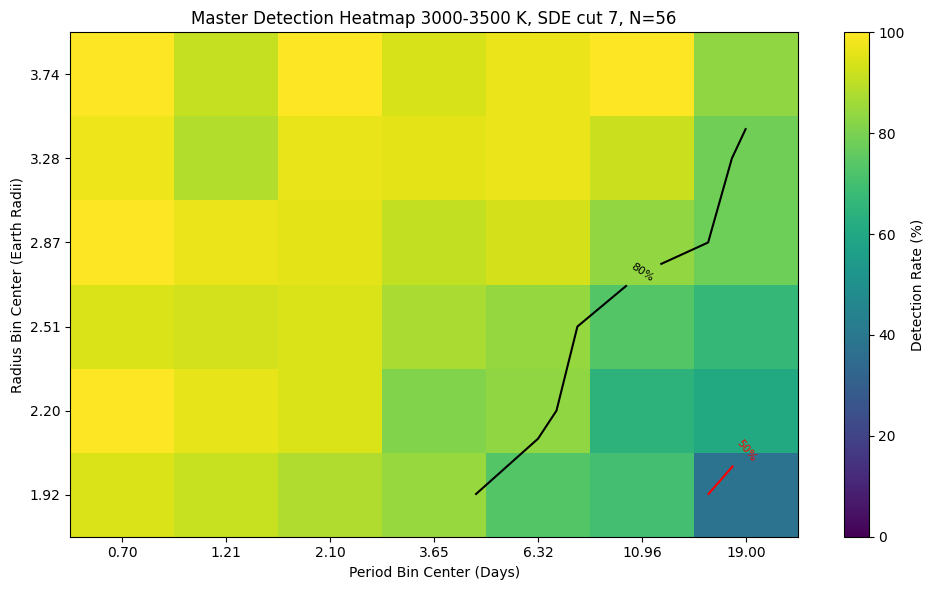

Removing 0 rows with missing stellar mass
Dataframe size after removal: 3683 rows
False positive cells: 51
Average radius of detected planets for SDE cut 7 and Stellar Temp range 3500-4000 K: 2.774 Earth radii


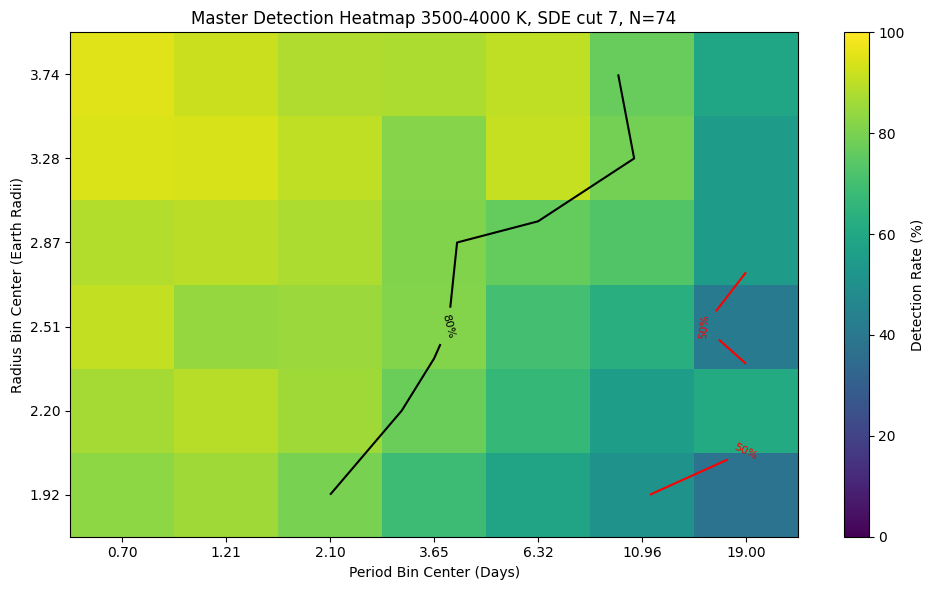

Removing 0 rows with missing stellar mass
Dataframe size after removal: 3077 rows
False positive cells: 48
Average radius of detected planets for SDE cut 7 and Stellar Temp range 4000-4500 K: 2.821 Earth radii


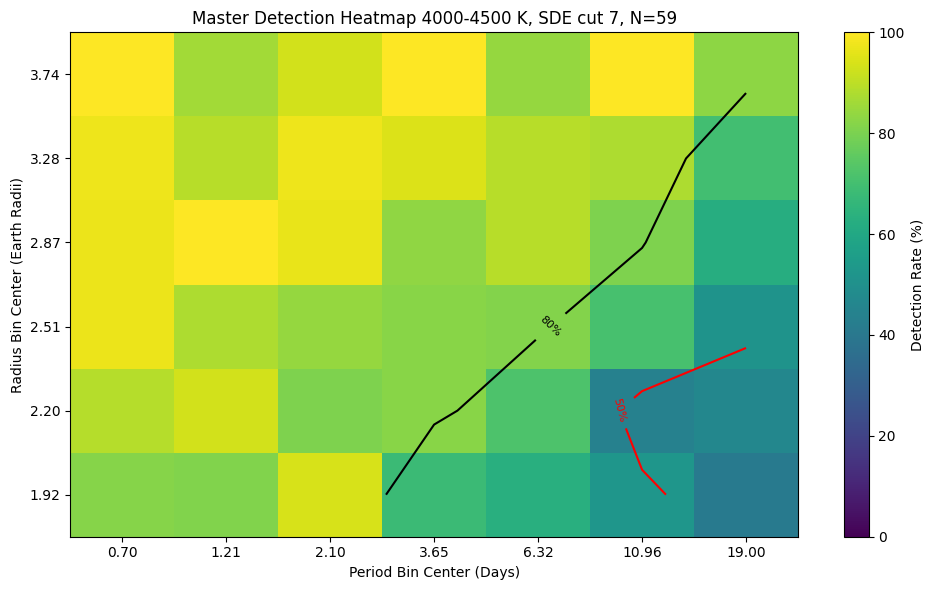

Removing 0 rows with missing stellar mass
Dataframe size after removal: 4322 rows
False positive cells: 56
Average radius of detected planets for SDE cut 7 and Stellar Temp range 4500-5000 K: 2.788 Earth radii


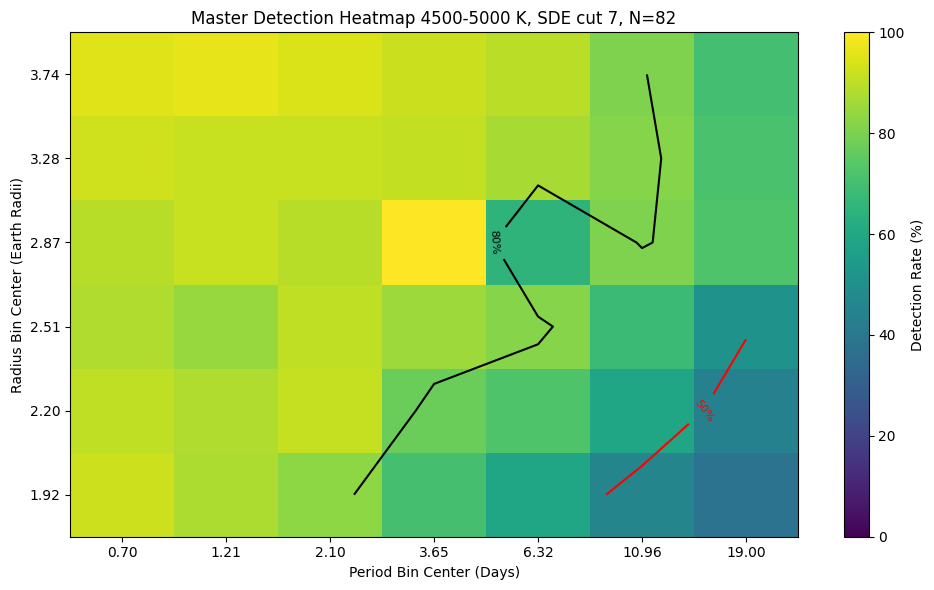

Removing 0 rows with missing stellar mass
Dataframe size after removal: 7305 rows
False positive cells: 101
Average radius of detected planets for SDE cut 7 and Stellar Temp range 5000-5500 K: 2.796 Earth radii


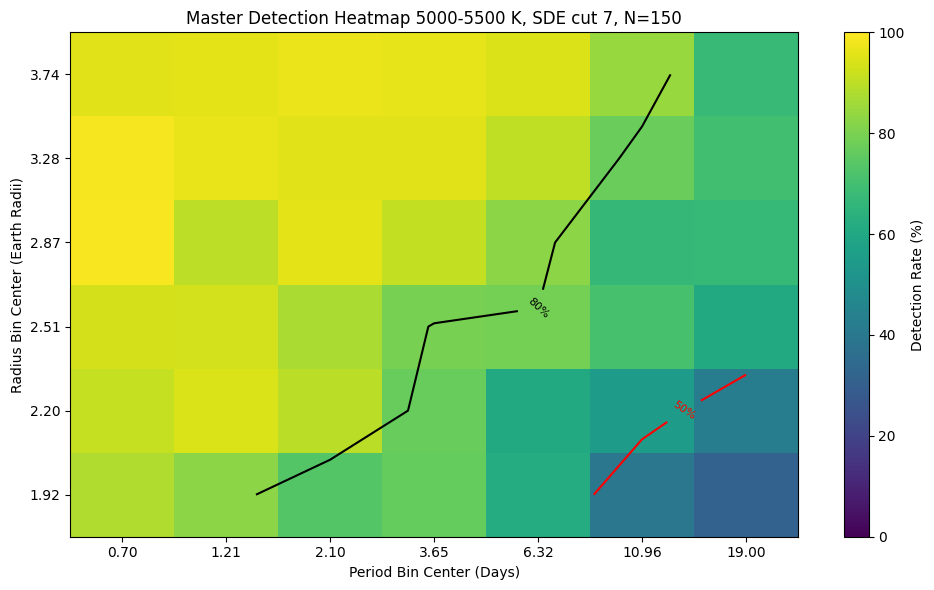

Removing 0 rows with missing stellar mass
Dataframe size after removal: 10516 rows
False positive cells: 166
Average radius of detected planets for SDE cut 7 and Stellar Temp range 5500-6000 K: 2.820 Earth radii


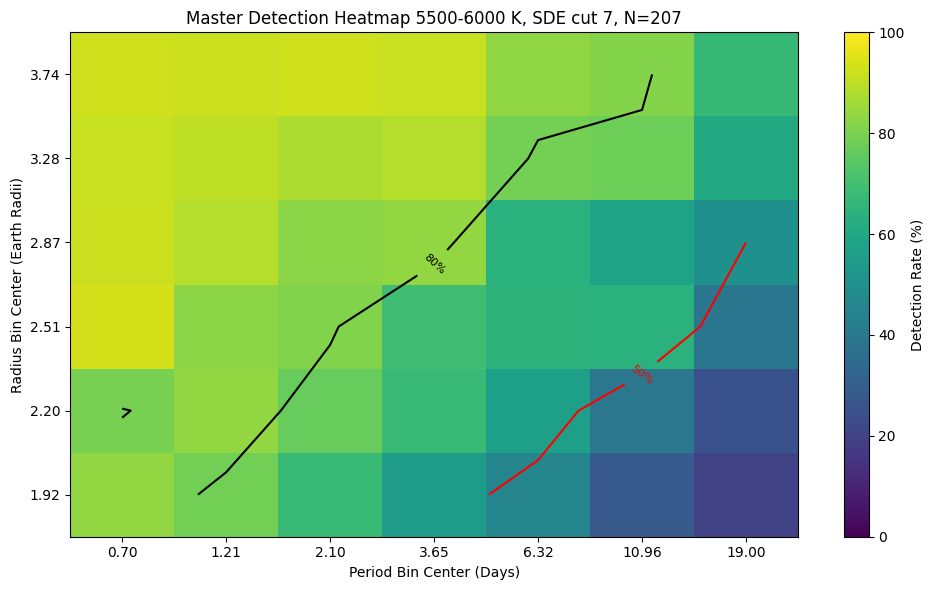

Removing 0 rows with missing stellar mass
Dataframe size after removal: 5999 rows
False positive cells: 77
Average radius of detected planets for SDE cut 7 and Stellar Temp range 6000-6500 K: 2.856 Earth radii


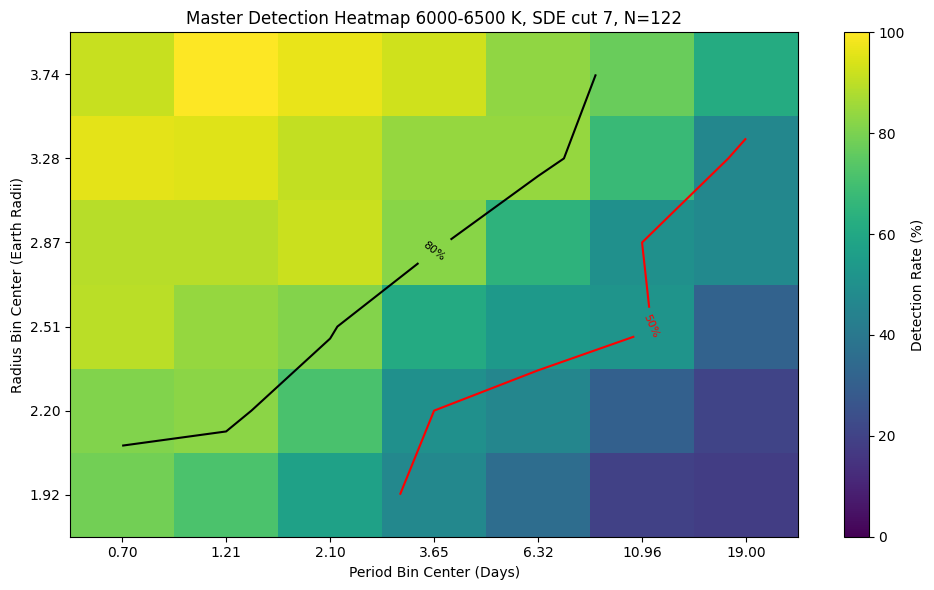

Removing 0 rows with missing stellar mass
Dataframe size after removal: 2158 rows
False positive cells: 37
Average radius of detected planets for SDE cut 7 and Stellar Temp range 6500-7000 K: 2.913 Earth radii


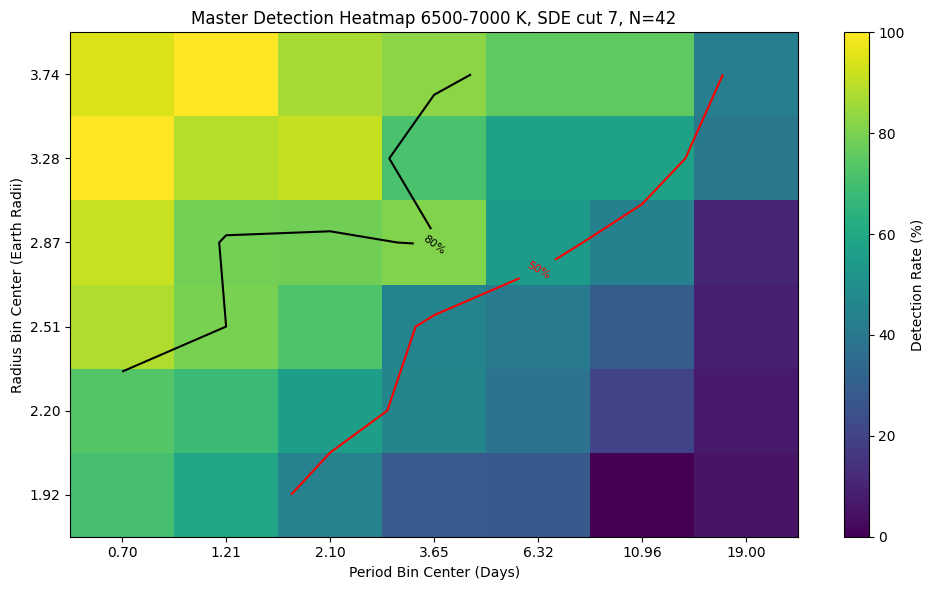

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from scipy.interpolate import griddata

def master_heatmap(df, sde_threshold, temp_range, periods_bins, radii_bins):
    """
    Generate master detection heatmap using bin centers framework.
    
    Parameters:
    -----------
    df : DataFrame
        Combined TLS results dataframe
    sde_threshold : float
        SDE threshold for detection
    temp_range : tuple
        (temp_min, temp_max) for stellar temperature filtering
    periods_bins : list of tuples
        Period bin edges as [(pmin, pmax), ...]
    radii_bins : list of tuples
        Radius bin edges as [(rmin, rmax), ...]
    """
    temp_min, temp_max = temp_range

    # Filter based on Stellar Temperature
    temp_lim = (df['Stellar Temperature'] >= temp_min) & (df['Stellar Temperature'] <= temp_max)
    df = df[temp_lim].copy()

    # Add geometric transit probability and filter false positives
    df = calc_geometric_transit_probability(df)
    df = filter_out_false_positives(df, sde_threshold)

    unique_tics = df['TIC'].unique()

    # Calculate bin centers for grouping
    radius_centers = [10**((np.log10(rmin) + np.log10(rmax))/2) for rmin, rmax in radii_bins]
    period_centers = [10**((np.log10(pmin) + np.log10(pmax))/2) for pmin, pmax in periods_bins]

    # Collect all detection results
    all_heatmap_rows = []

    for tic in unique_tics:
        try:
            tic_rows = df[df['TIC'] == tic]
            if tic_rows['True Radius (Earth Radii)'].isnull().all():
                print(f"No valid data for {tic}, skipping...")
                continue

            for _, row in tic_rows.iterrows():
                true_period = float(row['True Period (Days)'])
                true_radius = float(row['True Radius (Earth Radii)'])
                
                # Find which bin this period and radius fall into
                period_bin_center = None
                for i, (pmin, pmax) in enumerate(periods_bins):
                    if pmin <= true_period < pmax:
                        period_bin_center = period_centers[i]
                        break
                
                radius_bin_center = None
                for i, (rmin, rmax) in enumerate(radii_bins):
                    if rmin <= true_radius < rmax:
                        radius_bin_center = radius_centers[i]
                        break
                
                # Skip if outside bin ranges
                if period_bin_center is None or radius_bin_center is None:
                    continue

                try:
                    periods = row['TLS Periods array'].replace('[', '').replace(']', '').split()
                    sdes = row['TLS SDE > 7 array'].replace('[', '').replace(']', '').split()
                    periods = [float(p) for p in periods]
                    sdes = [float(s) for s in sdes]
                except:
                    continue

                # Periods with SDE above threshold
                periods_above_threshold = [
                    p for p, s in zip(periods, sdes) if s > sde_threshold
                ]
                
                # Include aliases (harmonics) for detection check
                aliases = [true_period, true_period / 2, true_period * 2, true_period / 3, true_period * 3]

                detected = any(
                    0.999 * alias < p < 1.001 * alias
                    for alias in aliases
                    for p in periods_above_threshold
                )

                all_heatmap_rows.append({
                    'radius_bin_center': radius_bin_center,
                    'period_bin_center': period_bin_center,
                    'Detection': int(detected),
                    'Transit Probability': row['Transit Probability']
                })

        except Exception as e:
            print(f"An error for TIC {tic} occurred: {e}")
            continue

    if all_heatmap_rows:
        heatmap_df = pd.DataFrame(all_heatmap_rows)
        heatmap_df['Detection'] = pd.to_numeric(heatmap_df['Detection'])

        # Group by bin centers, count detections and trials
        heatmap_counts = heatmap_df.groupby(
            ['radius_bin_center', 'period_bin_center']
        ).agg(
            detections=('Detection', 'sum'),
            trials=('Detection', 'count'),
            transit_prob=('Transit Probability', 'mean')
        ).reset_index()

        # Calculate detection rate for coloring
        heatmap_counts['detection_rate'] = heatmap_counts['detections'] / heatmap_counts['trials']

        # Pivot for heatmap coloring
        heatmap_pivot = heatmap_counts.pivot(
            index='radius_bin_center',
            columns='period_bin_center',
            values='detection_rate'
        )

        avg_detected_radius = heatmap_df.loc[heatmap_df['Detection'] == 1, 'radius_bin_center'].mean()
        print(f"Average radius of detected planets for SDE cut {sde_threshold} "
              f"and Stellar Temp range {temp_min}-{temp_max} K: {avg_detected_radius:.3f} Earth radii")

        # --- Plot heatmap with overlayed contours ---
        heatmap_pivot_sorted = heatmap_pivot.sort_index().sort_index(axis=1)
        Z = heatmap_pivot_sorted.values * 100  # Convert to percent

        plt.figure(figsize=(10, 6))

        # Use imshow to make uniform cells
        mesh = plt.imshow(
            Z,
            origin='upper',
            cmap='viridis',
            vmin=0, vmax=100,
            aspect='auto'
        )

        plt.colorbar(mesh, label='Detection Rate (%)')

        # Overlay contour lines
        X, Y = np.meshgrid(np.arange(len(period_centers)), np.arange(len(radius_centers)))
        CS = plt.contour(
            X, Y, Z,
            levels=[50, 80],
            colors=['red', 'black'],
            linewidths=1.5
        )
        plt.clabel(CS, inline=True, fontsize=8, fmt=lambda val: f"{int(val)}%")

        # Set tick labels to bin center values
        plt.xticks(np.arange(len(period_centers)), [f"{p:.2f}" for p in period_centers])
        plt.yticks(np.arange(len(radius_centers)), [f"{r:.2f}" for r in radius_centers])

        plt.gca().invert_yaxis()
        plt.xlabel('Period Bin Center (Days)')
        plt.ylabel('Radius Bin Center (Earth Radii)')
        plt.title(f'Master Detection Heatmap {temp_min}-{temp_max} K, SDE cut {sde_threshold}, N={len(unique_tics)}')
        plt.tight_layout()
        plt.show()

        # Save to CSV
        output_dir = './master_heatmaps/'
        import os
        os.makedirs(output_dir, exist_ok=True)
        output_filename = f'master_heatmap_{temp_min}_{temp_max}_K_sde_{sde_threshold}.csv'
        heatmap_counts.to_csv(os.path.join(output_dir, output_filename), index=False)


# --- Setup bins (same as working cell) ---
radius_bin_edges = np.logspace(np.log10(1.8), np.log10(4.0), num=7)
radii_bins = [(radius_bin_edges[i], radius_bin_edges[i+1]) for i in range(len(radius_bin_edges)-1)]

periods_centers = np.logspace(np.log10(0.7), np.log10(19), num=7)
periods_centers = [float(f"{v:.3f}") for v in periods_centers]
periods_log = np.log10(periods_centers)
log_step = periods_log[1] - periods_log[0]
period_bin_edges = [10**(periods_log[0] - log_step/2)]
period_bin_edges.extend([10**((periods_log[i] + periods_log[i+1])/2) for i in range(len(periods_log)-1)])
period_bin_edges.append(10**(periods_log[-1] + log_step/2))
periods_bins = [(period_bin_edges[i], period_bin_edges[i+1]) for i in range(len(period_bin_edges)-1)]

print("Period bins:", periods_bins)
print("Radius bins:", radii_bins)

# --- Load and prepare data ---
csv_files = glob.glob("./take_two_tls_results_per_tic/*")

problem_files = []
for f in csv_files:
    try:
        pd.read_csv(f, engine="python")
    except Exception as e:
        print(f"Problem reading {f}: {e}")
        problem_files.append(f)

csv_files = [f for f in csv_files if f not in problem_files]
df_list = [pd.read_csv(f) for f in csv_files]

df = pd.concat(df_list, ignore_index=True)
df = df[['TIC', 'True Radius (Earth Radii)', 'True Period (Days)', 'Detection', '# trials', 
         'TLS Periods array', 'TLS SDE > 7 array', 'Stellar Radius', 'Stellar Temperature']]
df = df.drop_duplicates(subset=['TIC', 'True Radius (Earth Radii)', 'True Period (Days)', '# trials'])

# --- Run master_heatmap for all temperature ranges ---
sde_threshold = 7
temp_ranges = [(3000, 3500), (3500, 4000), (4000, 4500), (4500, 5000), 
               (5000, 5500), (5500, 6000), (6000, 6500), (6500, 7000)]

for temp_range in temp_ranges:
    master_heatmap(df, sde_threshold, temp_range, periods_bins=periods_bins, radii_bins=radii_bins)

Removing 0 rows with missing stellar mass
Dataframe size after removal: 2728 rows
False positive cells: 37
Removing 0 rows with missing stellar mass
Dataframe size after removal: 7305 rows
False positive cells: 101
Removing 0 rows with missing stellar mass
Dataframe size after removal: 2158 rows
False positive cells: 37


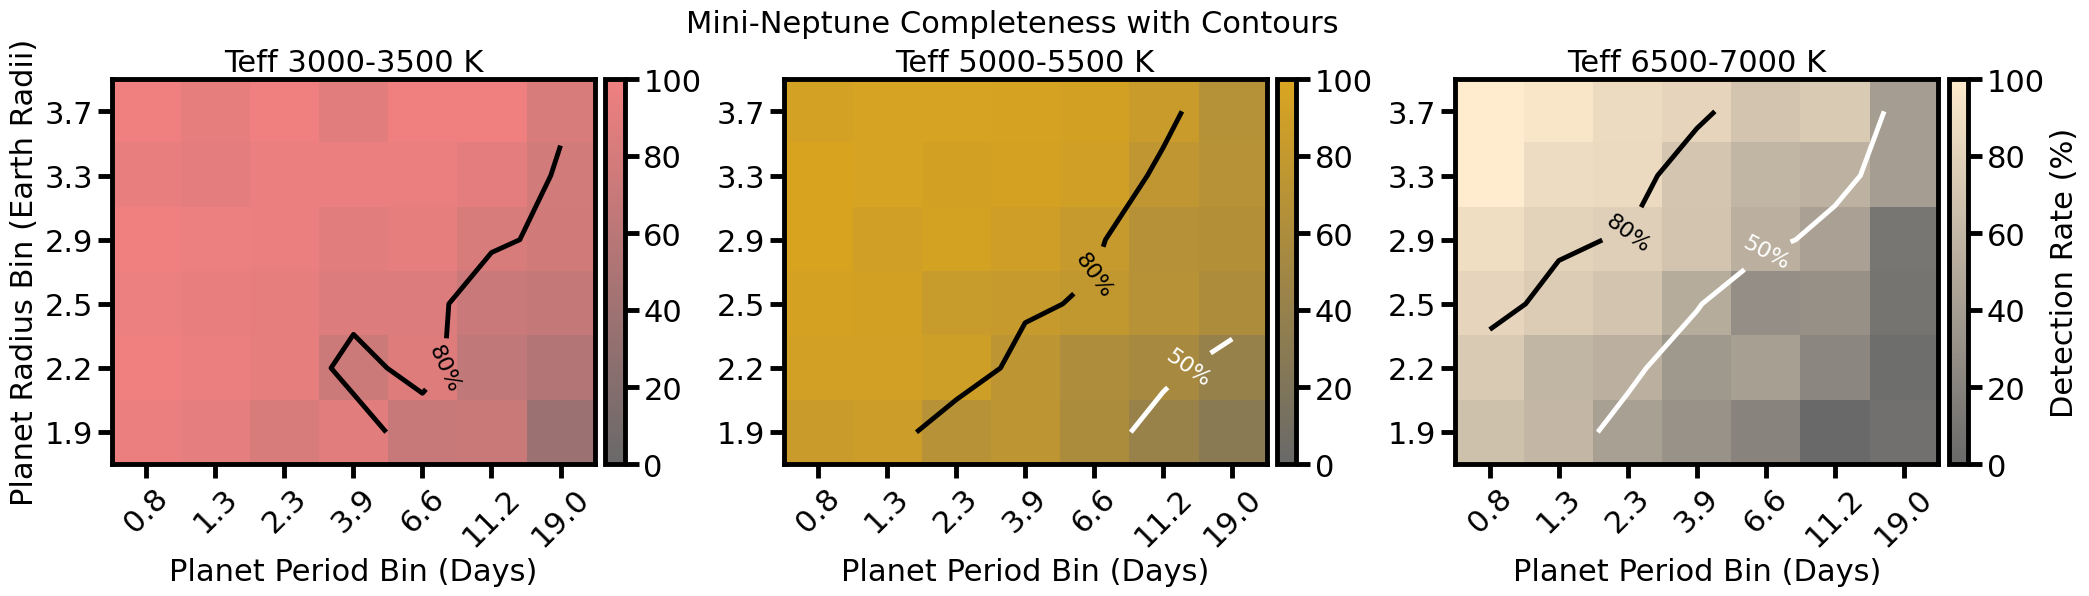

In [3]:
#
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
from scipy.interpolate import griddata
from matplotlib.patheffects import withStroke

# --- Parameters ---
sde_threshold = 7
# Choose three representative temperature bins
selected_temp_ranges = [(3000, 3500), (5000, 5500), (6500, 7000)]
# These should match the bins in your data and histograms
# Log-spaced bin edges (from your requested bins)
period_bins = [(0.602879601886859, 1.0247419187288085), 
               (1.0247419187288085, 1.7422376416551217), 
               (1.7422376416551217, 2.962555653485686), 
               (2.962555653485686, 5.037847754746068), 
               (5.037847754746068, 8.567765753100398), 
               (8.567765753100398, 14.570072065710583),
                 (14.570072065710583, 24.771115083775257)]


radius_bins = [
    (1.8, 2.056223979157517),
    (2.056223979157517, 2.348920584701318),
    (2.348920584701318, 2.6832815729997477),
    (2.6832815729997477, 3.0652377295742124),
    (3.0652377295742124, 3.501564067427134),
    (3.501564067427134, 4.0),
]

# Use geometric bin centers for nearest-bin assignment
period_vals = np.array([np.sqrt(lo * hi) for lo, hi in period_bins])
radius_vals = np.array([np.sqrt(lo * hi) for lo, hi in radius_bins])

fig, axes = plt.subplots(1, 3, figsize=(24, 5))

from matplotlib.colors import LinearSegmentedColormap

for i, temp_range in enumerate(selected_temp_ranges):
    temp_min, temp_max = temp_range
    # Filter based on Stellar Temperature
    temp_lim = (df['Stellar Temperature'] >= temp_min) & (df['Stellar Temperature'] <= temp_max)
    df_temp = df[temp_lim]
    # Remove rows with missing stellar mass
    df_temp = calc_geometric_transit_probability(df_temp)
    df_temp = filter_out_false_positives(df_temp, sde_threshold)
    unique_tics = df_temp['TIC'].unique()
    # Collect all detection results here
    all_heatmap_rows = []
    for tic in unique_tics:
        try:
            tic_rows = df_temp[df_temp['TIC'] == tic]
            if tic_rows['True Radius (Earth Radii)'].isnull().all():
                continue
            for _, row in tic_rows.iterrows():
                true_period = float(row['True Period (Days)'])
                try:
                    periods = row['TLS Periods array'].replace('[', '').replace(']', '').split()
                    sdes = row['TLS SDE > 7 array'].replace('[', '').replace(']', '').split()
                    periods = [float(p) for p in periods]
                    sdes = [float(s) for s in sdes]
                except:
                    continue
                periods_above_threshold = [p for p, s in zip(periods, sdes) if s > sde_threshold]
                aliases = [true_period, true_period / 2, true_period * 2, true_period / 3, true_period * 3]
                detected = any(0.999 * alias < p < 1.001 * alias for alias in aliases for p in periods_above_threshold)
                all_heatmap_rows.append({
                    'True Radius (Earth Radii)': row['True Radius (Earth Radii)'],
                    'True Period (Days)': row['True Period (Days)'],
                    'Detection': int(detected),
                    'Transit Probability': row['Transit Probability']
                })
        except Exception as e:
            print(f"An error for TIC {tic} occurred: {e}")
            continue
    if all_heatmap_rows:
        heatmap_df = pd.DataFrame(all_heatmap_rows)
        heatmap_df['Detection'] = pd.to_numeric(heatmap_df['Detection'])
        
        # Bin data using interval-based binning (pmin <= value < pmax)
        # Calculate bin centers for grouping
        period_centers = [np.sqrt(lo * hi) for lo, hi in period_bins]
        radius_centers = [np.sqrt(lo * hi) for lo, hi in radius_bins]
        
        # Assign bin centers based on which interval each value falls into
        binned_rows = []
        for _, row in heatmap_df.iterrows():
            true_period = row['True Period (Days)']
            true_radius = row['True Radius (Earth Radii)']
            
            # Find period bin
            period_bin_center = None
            for j, (pmin, pmax) in enumerate(period_bins):
                if pmin <= true_period < pmax:
                    period_bin_center = period_centers[j]
                    break
            
            # Find radius bin
            radius_bin_center = None
            for j, (rmin, rmax) in enumerate(radius_bins):
                if rmin <= true_radius < rmax:
                    radius_bin_center = radius_centers[j]
                    break
            
            # Skip if outside bin ranges
            if period_bin_center is None or radius_bin_center is None:
                continue
            
            binned_rows.append({
                'radius_bin': radius_bin_center,
                'period_bin': period_bin_center,
                'Detection': row['Detection']
            })
        
        if not binned_rows:
            continue
            
        binned_df = pd.DataFrame(binned_rows)
        
        # Group by binned values, count detections and trials
        heatmap_counts = binned_df.groupby(['radius_bin', 'period_bin']).agg(
            detections=('Detection', 'sum'),
            trials=('Detection', 'count')
        ).reset_index()
        
        # Calculate detection rate for coloring
        heatmap_counts['detection_rate'] = heatmap_counts['detections'] / heatmap_counts['trials']
        
        # Pivot for heatmap coloring
        heatmap_pivot = heatmap_counts.pivot(
            index='radius_bin',
            columns='period_bin',
            values='detection_rate'
        )
        
        # Reindex to ensure all bins are present (fill missing with NaN)
        heatmap_pivot = heatmap_pivot.reindex(index=radius_vals, columns=period_vals)
        Z = heatmap_pivot.values * 100  # Convert to percent scale
        ax = axes[i]
        # Set colormap: top panel (i==0) gets black-to-lightcoral, middle black-to-goldenrod, bottom black-to-blanchedalmond
        if i == 0:
            coral_cmap = LinearSegmentedColormap.from_list('black_coral', ['dimgrey', 'lightcoral'])
            mesh = ax.imshow(
                Z,
                origin='upper',
                cmap=coral_cmap,
                vmin=0, vmax=100,
                aspect='auto'
            )
        elif i == 1:
            gold_cmap = LinearSegmentedColormap.from_list('black_gold', ['dimgrey', 'goldenrod'])
            mesh = ax.imshow(
                Z,
                origin='upper',
                cmap=gold_cmap,
                vmin=0, vmax=100,
                aspect='auto'
            )
        elif i == 2:
            almond_cmap = LinearSegmentedColormap.from_list('black_almond', ['dimgrey', 'blanchedalmond'])
            mesh = ax.imshow(
                Z,
                origin='upper',
                cmap=almond_cmap,
                vmin=0, vmax=100,
                aspect='auto'
            )

        
        # Overlay contour (same grid) - adaptive levels based on data
        X, Y = np.meshgrid(np.arange(len(period_vals)), np.arange(len(radius_vals)))
        
        # Determine contour levels based on max value in this panel
        max_val = np.nanmax(Z)
        if max_val >= 80:
            contour_levels = [50, 80]
            contour_colors = ['white', 'black']
        elif max_val >= 50:
            contour_levels = [50]
            contour_colors = ['white']
        elif max_val >= 30:
            contour_levels = [30, max_val * 0.9]
            contour_colors = ['white', 'black']
        else:
            contour_levels = [max_val * 0.5, max_val * 0.8]
            contour_colors = ['white', 'black']
        
        # Remove 50% contour for first panel only (M-stars)
        if i == 0 and 50 in contour_levels:
            idx_50 = contour_levels.index(50)
            contour_levels.pop(idx_50)
            contour_colors.pop(idx_50)
        
        CS = ax.contour(
            X, Y, Z,
            levels=contour_levels,
            colors=contour_colors,
            linewidths=3.5  # Thicker contour lines
        )
        ax.clabel(CS, inline=True, fontsize=16, fmt=lambda val: f"{int(val)}%")  # Thicker contour labels

        # Set tick labels to actual period/radius values
        ax.set_xticks(np.arange(len(period_vals)))
        ax.set_xticklabels([f"{p:.1f}" for p in period_vals], fontsize=22, rotation=45)
        ax.set_yticks(np.arange(len(radius_vals)))
        ax.set_yticklabels([f"{r:.1f}" for r in radius_vals], fontsize=22)
        ax.invert_yaxis()
        # Only show y-axis label on leftmost panel
        if i == 0:
            ax.set_ylabel('Planet Radius Bin (Earth Radii)', fontsize=22)
        else:
            ax.set_ylabel('')
        # Show x-axis label on all panels
        ax.set_xlabel('Planet Period Bin (Days)', fontsize=22)
        ax.set_title(f'Teff {temp_min}-{temp_max} K', fontsize=22)

        # Make all axis ticks and lines thicker
        ax.tick_params(axis='both', which='major', width=3.5, length=10)
        ax.tick_params(axis='both', which='minor', width=2.5, length=6)
        for spine in ax.spines.values():
            spine.set_linewidth(3.5)

        # Add colorbar to all subplots, but only label the rightmost one
        cbar = fig.colorbar(mesh, ax=ax, orientation='vertical', fraction=0.045, pad=0.02)
        if i == 2:
            cbar.set_label('Detection Rate (%)', fontsize=22)
        cbar.ax.tick_params(labelsize=22, width=3.5, length=10)
        for spine in cbar.ax.spines.values():
            spine.set_linewidth(3.5)
        

# # Add spectral type labels at the top of each panel
# outline = [withStroke(linewidth=1.5, foreground='black')]

# # Left panel (M-stars): lightcoral label
# ax1 = axes[0]
# xmin, xmax = ax1.get_xlim()
# x_positions = np.linspace(xmin, xmax, 3)
# y_top = ax1.get_ylim()[0] - 0.6  # Position above the plot
# ax1.text(x_positions[1], y_top, 'M', color='lightcoral', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)

# # Middle panel (GK-stars): goldenrod label
# ax2 = axes[1]
# xmin, xmax = ax2.get_xlim()
# x_positions = np.linspace(xmin, xmax, 3)
# y_top = ax2.get_ylim()[0] - 0.6
# ax2.text(x_positions[1], y_top, 'GK', color='goldenrod', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)

# # Right panel (F-stars): blanchedalmond label
# ax3 = axes[2]
# xmin, xmax = ax3.get_xlim()
# x_positions = np.linspace(xmin, xmax, 3)
# y_top = ax3.get_ylim()[0] - 0.6
# ax3.text(x_positions[1], y_top, 'F', color='blanchedalmond', fontsize=30, va='top', ha='center', fontweight='bold', path_effects=outline)


#plt.tight_layout(rect=[0, 0, 1, -.5])  # Add separation between plots and suptitle
plt.subplots_adjust(wspace=0.3)        # Increase horizontal space between subplots
plt.suptitle('Mini-Neptune Completeness with Contours', y=1.02, fontsize=22)
plt.show()

# Save the figure to a PNG file
fig.savefig("completeness_maps_with_contours.png", dpi=300, bbox_inches='tight')
